# REMOVING UNSW AND USING CIC2023 AND 2017


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Device: cpu | torch: 2.6.0+cpu

✅ GLOBAL_FEATURES dim = 58
Example first 20: ['ack_count', 'ack_flag_number', 'arp', 'avg', 'covariance', 'cwr_flag_number', 'daddr', 'dhcp', 'dns', 'dport', 'drate', 'duration', 'ece_flag_number', 'fin_count', 'fin_flag_number', 'flow_duration', 'header_length', 'http', 'https', 'iat']

CSVs in current dir: ['CIC.csv', 'CIC2.csv', 'DNN-EdgeIIoT-dataset.csv', 'IoT_Botnet_Final_10_best_Training.csv', 'NUSW-NB15_features.csv', 'TON_IoT_Train_Test_Network.csv', 'UNSW-NB15_1.csv', 'UNSW-NB15_2.csv', 'UNSW-NB15_3.csv', 'UNSW-NB15_4.csv', 'UNSW-NB15_LIST_EVENTS.csv', 'UNSW.csv', 'UNSW_NB15.csv', 'UNSW_NB15_testing-set.csv']
CIC23 CIC.csv exists= True
⚠️ [CIC23] benign seems reversed -> flipping.
CIC23 X=(54506, 58) y=[53303  1203] attack%=0.0221
CIC17 CIC2.csv exists= True
⚠️ [CIC17] benign seems reversed -> flipping.
CIC17 X=(400000, 58) y=[388771  11229] attack%=0.0281
BOT IoT_Botnet_Final_10_best_Training.csv exists= True
BOT   X=(500000, 58) y=[    60 4999

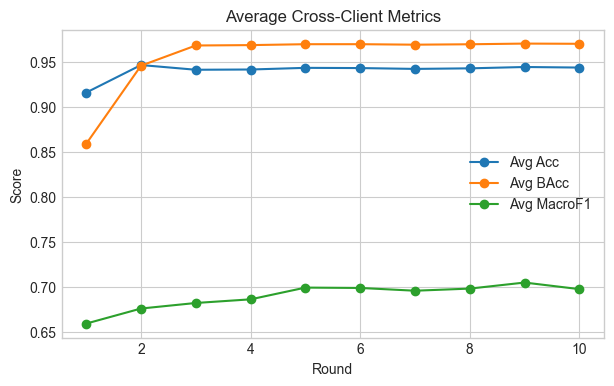

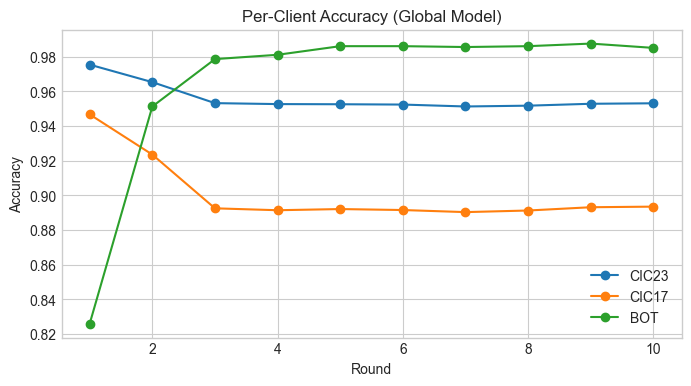

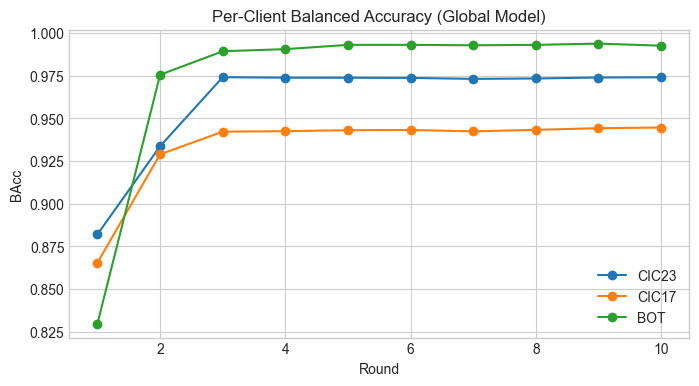

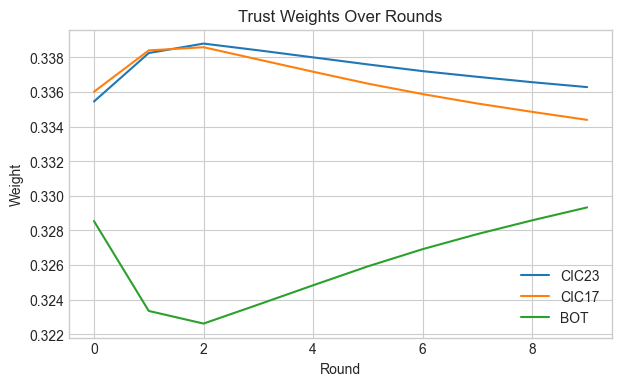


Per-round time/memory:
 Round  Time(s)  Mem(MB)
     1    11.12   759.47
     2    10.31   756.42
     3    10.70   755.64
     4    10.28   755.93
     5    10.94   755.65
     6    10.71   756.42
     7    10.52   756.14
     8    10.95   755.94
     9    10.54   756.15
    10    11.01   756.44

[CIC23] FINAL thr=0.95 | Acc=0.9531 


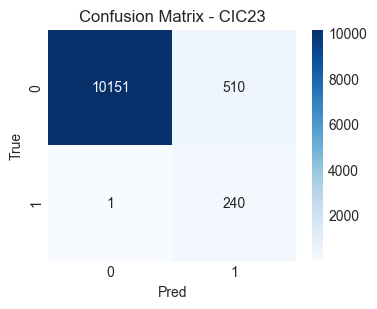

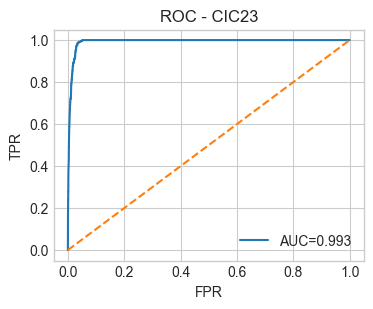

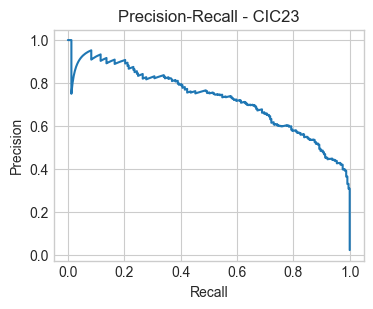


[CIC17] FINAL thr=0.95 | Acc=0.8935 


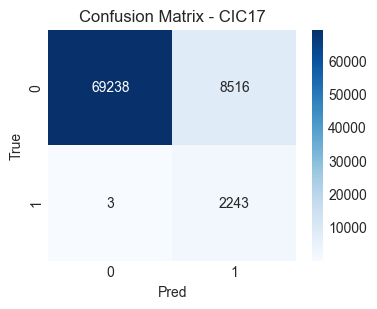

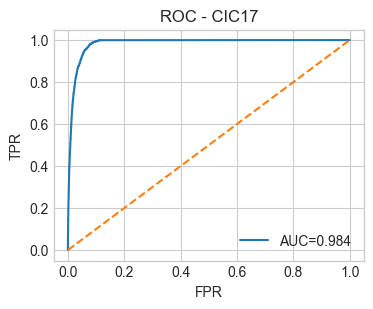

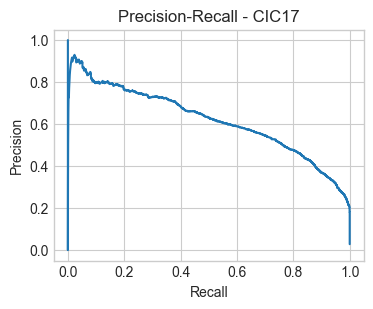


[BOT] FINAL thr=0.65 | Acc=0.9851 


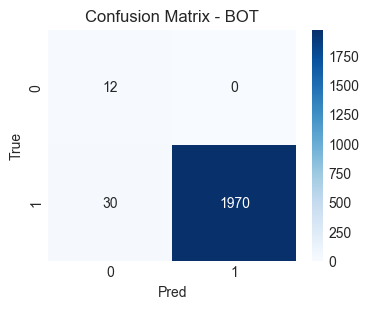

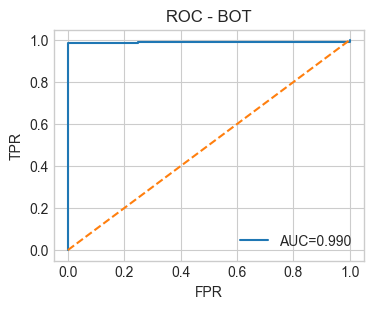

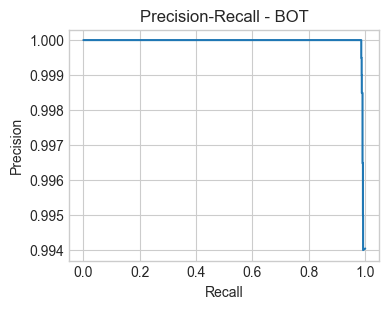

In [ ]:
# =============================================================================
# FULL CODE (CIC23 + CIC17 + BOT): Feature-Selected + FedBN + FedProx + Trust
# FIXES ADDED FOR YOUR CASE:
# ✅ Robust label parsing (CIC benign flipping, BOT attack)
# ✅ Build GLOBAL_FEATURES from CIC feature list + BOT list (union)
# ✅ Per-dataset vectorization into same feature space (missing => 0)
# ✅ Clean numeric (NaN/inf) + safe float32
# ✅ Split BOT with forced benign distribution (your BOT has ~60 benign only!)
# ✅ Feature selection: MI on mixed sample + FORCE important BOT features included
# ✅ FedBN (BN local per client) + FedProx + Balanced Sampler + sample cap
# ✅ Threshold tuning: BOT uses Balanced Accuracy threshold; CIC uses MacroF1
# ✅ Per-round: AvgAcc + AvgBAcc + AvgMacroF1 + trust + per-client metrics
# ✅ Final: per-client Confusion Matrix + ROC + PR
# =============================================================================

!pip -q install psutil seaborn scikit-learn pandas matplotlib

import os, random, time, psutil, glob
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)
from sklearn.feature_selection import mutual_info_classif

import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Config
# ----------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE, "| torch:", torch.__version__)

# ----------------------------
# 1) PUT YOUR CSV PATHS HERE
# ----------------------------
CLIENT_CSV = {
    "CIC23": "/content/CIC.csv",                          # your CIC 2023 file name/path
    "CIC17": "/content/CICIDS2017.csv",                         # your CIC 2017 file name/path
    "BOT":   "/content/IoT_Botnet_Final_10_best_Training.csv",
}

# label columns you confirmed
LABEL_COLS = {"CIC23": "benign", "CIC17": "benign", "BOT": "attack"}

# To keep runtime reasonable on CPU
MAX_ROWS = {"CIC23": 200000, "CIC17": 400000, "BOT": 500000}  # adjust as you want

# Federated training settings
ROUNDS = 10
LOCAL_EPOCHS = 2
BATCH_SIZE = 1024
LR = 5e-4

# cap samples per client per round to avoid domination (important!)
N_PER_ROUND = 80000   # try 30000-60000 if CPU too slow

# FedProx
MU_FEDPROX = 0.01     # try 0.001 / 0.01 / 0.05

# Trust aggregation
USE_TRUST = True

# Evaluation cap
EVAL_MAX = 200000     # None for full eval (slow)

# Feature selection
TOPK = 35             # was 25; increase to help BOT
MI_SAMPLES_PER_CLIENT = 60000  # sample per client for MI

# ----------------------------
# 2) Feature lists (you provided)
# ----------------------------
CIC_FEATURES = [
 'flow_duration', 'header_length', 'protocol_type', 'duration', 'rate',
 'srate', 'drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number',
 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'http',
 'https', 'dns', 'telnet', 'smtp', 'ssh', 'irc', 'tcp', 'udp', 'dhcp', 'arp',
 'icmp', 'ipv', 'llc', 'tot_sum', 'min', 'max', 'avg', 'std', 'tot_size',
 'iat', 'number', 'magnitue', 'radius', 'covariance', 'variance', 'weight'
]  # label "benign" is separate

BOT_FEATURES = [
 'pkSeqID','proto','saddr','sport','daddr','dport','seq','stddev',
 'N_IN_Conn_P_SrcIP','min','state_number','mean','N_IN_Conn_P_DstIP',
 'drate','srate','max'
]  # label "attack" is separate

# Union feature space (lowercased)
GLOBAL_FEATURES = sorted(list({c.lower().strip() for c in (CIC_FEATURES + BOT_FEATURES)}))
print("\n✅ GLOBAL_FEATURES dim =", len(GLOBAL_FEATURES))
print("Example first 20:", GLOBAL_FEATURES[:20])

# ----------------------------
# 3) Helpers
# ----------------------------
def clean_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    df = df.replace([np.inf, -np.inf], np.nan)
    return df

def safe_to_float(df: pd.DataFrame, col: str) -> pd.Series:
    if col not in df.columns:
        return pd.Series(np.zeros(len(df), dtype=np.float32))
    return pd.to_numeric(df[col], errors="coerce").fillna(0.0)

def vectorize_to_global(df: pd.DataFrame, global_feats) -> np.ndarray:
    """
    Build X with columns in global_feats order.
    Missing columns => 0. Non-numeric columns => coerced to numeric (NaN->0).
    """
    df = clean_df(df)
    cols = []
    n = len(df)
    for f in global_feats:
        if f in df.columns:
            s = pd.to_numeric(df[f], errors="coerce").fillna(0.0)
        else:
            s = pd.Series(np.zeros(n, dtype=np.float32))
        cols.append(s.astype(np.float32))
    X = np.stack([c.values for c in cols], axis=1).astype(np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return X

def extract_labels(df: pd.DataFrame, name: str) -> np.ndarray:
    df = clean_df(df)
    col = LABEL_COLS[name].lower()
    if col not in df.columns:
        raise ValueError(f"[{name}] missing label col '{col}'. Available: {df.columns[:20].tolist()}...")

    y = df[col]

    # CIC benign handling: want y=1 attack, y=0 benign
    if name.startswith("CIC"):
        if y.dtype == bool:
            b = y.astype(int).values  # True=1 (could be benign)
        elif pd.api.types.is_numeric_dtype(y):
            b = pd.to_numeric(y, errors="coerce").fillna(0).astype(int).values
        else:
            s = y.astype(str).str.lower().str.strip()
            b = np.where(s.str.contains("benign|normal|true|yes") | s.eq("1"), 1, 0).astype(int)

        # if benign proportion is tiny, likely reversed
        if b.mean() < 0.5:
            print(f"⚠️ [{name}] benign seems reversed -> flipping.")
            b = 1 - b
        # convert benign->0, attack->1
        return (1 - b).astype(np.int64)

    # BOT attack handling: want y=1 attack, y=0 benign
    if name == "BOT":
        if pd.api.types.is_numeric_dtype(y):
            yv = pd.to_numeric(y, errors="coerce").fillna(0).values
            return (yv != 0).astype(np.int64)
        s = y.astype(str).str.lower().str.strip()
        return (~s.isin(["0", "benign", "normal", "false"])).astype(np.int64).values

    raise ValueError("Unknown dataset")

def load_client(name: str, path: str, max_rows: int):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{name} file not found: {path}")
    df = pd.read_csv(path, nrows=max_rows, low_memory=False, on_bad_lines="skip")
    df = clean_df(df)
    y = extract_labels(df, name)
    X = vectorize_to_global(df, GLOBAL_FEATURES)

    dist = np.bincount(y, minlength=2)
    print(f"{name:5s} X={X.shape} y={dist} attack%={y.mean():.4f}")
    return X, y

def split_client_special(X, y, name, test_size=0.2, val_size=0.1):
    """
    Normal datasets: stratified split.
    BOT: force benign distribution (your BOT has extremely few benign).
    """
    if name != "BOT":
        Xt, Xte, yt, yte = train_test_split(
            X, y, test_size=test_size, random_state=SEED,
            stratify=y if len(np.unique(y)) > 1 else None
        )
        Xtr, Xva, ytr, yva = train_test_split(
            Xt, yt, test_size=val_size, random_state=SEED,
            stratify=yt if len(np.unique(yt)) > 1 else None
        )
        return (Xtr, ytr), (Xva, yva), (Xte, yte)

    idx0 = np.where(y == 0)[0]  # benign
    idx1 = np.where(y == 1)[0]  # attack
    np.random.shuffle(idx0); np.random.shuffle(idx1)

    n0 = len(idx0)
    if n0 < 20:
        print("⚠️ BOT benign is extremely tiny. BAcc will be unstable. Proceeding anyway...")

    n0_te = max(10, int(test_size * n0))
    n0_va = max(10, int(val_size * n0))
    n0_tr = n0 - n0_te - n0_va
    if n0_tr < 5:
        n0_tr = max(5, n0_tr)
        n0_va = max(2, min(n0_va, n0 - n0_tr))
        n0_te = max(2, n0 - n0_tr - n0_va)

    te0 = idx0[:n0_te]
    va0 = idx0[n0_te:n0_te + n0_va]
    tr0 = idx0[n0_te + n0_va:]

    # attacks: keep a controlled multiple of benign to avoid pure attack learning
    # (still imbalanced, but not insane)
    tr1 = idx1[:max(50 * len(tr0), 5000)]
    va1 = idx1[max(50 * len(tr0), 5000):max(50 * len(tr0), 5000) + max(50 * len(va0), 2000)]
    te1 = idx1[max(50 * len(tr0), 5000) + max(50 * len(va0), 2000):
              max(50 * len(tr0), 5000) + max(50 * len(va0), 2000) + max(50 * len(te0), 2000)]

    tr = np.concatenate([tr0, tr1])
    va = np.concatenate([va0, va1])
    te = np.concatenate([te0, te1])
    np.random.shuffle(tr); np.random.shuffle(va); np.random.shuffle(te)

    return (X[tr], y[tr]), (X[va], y[va]), (X[te], y[te])

def standardize_global(client_dict):
    scaler = StandardScaler().fit(np.concatenate([client_dict[n]["Xtr"] for n in client_dict], axis=0))
    for n in client_dict:
        client_dict[n]["Xtr"] = scaler.transform(client_dict[n]["Xtr"]).astype(np.float32)
        client_dict[n]["Xva"] = scaler.transform(client_dict[n]["Xva"]).astype(np.float32)
        client_dict[n]["Xte"] = scaler.transform(client_dict[n]["Xte"]).astype(np.float32)
    return scaler

def class_weights(y_np):
    c0 = max(int((y_np == 0).sum()), 1)
    c1 = max(int((y_np == 1).sum()), 1)
    w0 = (c0 + c1) / (2 * c0)
    w1 = (c0 + c1) / (2 * c1)
    return torch.tensor([w0, w1], dtype=torch.float32, device=DEVICE)

def make_balanced_loader(X, y, batch_size=BATCH_SIZE, max_n=N_PER_ROUND):
    n = len(y)
    if max_n is not None and n > max_n:
        idx = np.random.choice(n, max_n, replace=False)
        X = X[idx]; y = y[idx]

    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)

    c0 = max((y == 0).sum(), 1)
    c1 = max((y == 1).sum(), 1)
    w0 = 1.0 / c0
    w1 = 1.0 / c1
    sample_w = np.where(y == 0, w0, w1).astype(np.float64)

    sampler = WeightedRandomSampler(weights=sample_w, num_samples=len(sample_w), replacement=True)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, sampler=sampler)

def fedprox_loss(local_model, global_model, base_loss, mu=MU_FEDPROX):
    prox = 0.0
    for p_local, p_global in zip(local_model.parameters(), global_model.parameters()):
        prox = prox + torch.sum((p_local - p_global.detach()) ** 2)
    return base_loss + (mu / 2.0) * prox

def get_state(m): return {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
def set_state(m, s): m.load_state_dict(s, strict=True)

def is_bn_key(k: str) -> bool:
    return ("bn" in k.lower()) or ("running_mean" in k.lower()) or ("running_var" in k.lower()) or ("num_batches_tracked" in k.lower())

@torch.no_grad()
def predict_probs(model, X, bs=8192):
    model.eval()
    if EVAL_MAX is not None and len(X) > EVAL_MAX:
        idx = np.random.choice(len(X), EVAL_MAX, replace=False)
        X = X[idx]
    Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    outs = []
    for i in range(0, len(Xt), bs):
        outs.append(model(Xt[i:i+bs]))
    logits = torch.cat(outs, 0)
    return torch.softmax(logits, 1)[:, 1].cpu().numpy()

def balanced_accuracy(y_true, y_pred):
    # binary
    tp = ((y_pred==1) & (y_true==1)).sum()
    tn = ((y_pred==0) & (y_true==0)).sum()
    fp = ((y_pred==1) & (y_true==0)).sum()
    fn = ((y_pred==0) & (y_true==1)).sum()
    tpr = tp/(tp+fn+1e-12)
    tnr = tn/(tn+fp+1e-12)
    return 0.5*(tpr+tnr)

def macro_f1_binary(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

def best_thr_for_macro_f1(model, X, y, ts=np.linspace(0.05,0.95,19), max_eval=120000):
    if max_eval is not None and len(y) > max_eval:
        idx = np.random.choice(len(y), max_eval, replace=False)
        X = X[idx]; y = y[idx]
    probs = predict_probs(model, X)
    best_t, best_s = 0.5, -1
    for t in ts:
        pred = (probs >= t).astype(int)
        s = macro_f1_binary(y, pred)
        if s > best_s:
            best_s = s
            best_t = float(t)
    return best_t, float(best_s)

def best_thr_for_bacc(model, X, y, ts=np.linspace(0.01,0.99,33), max_eval=120000):
    if max_eval is not None and len(y) > max_eval:
        idx = np.random.choice(len(y), max_eval, replace=False)
        X = X[idx]; y = y[idx]
    probs = predict_probs(model, X)
    best_t, best_s = 0.5, -1
    for t in ts:
        pred = (probs >= t).astype(int)
        s = balanced_accuracy(y, pred)
        if s > best_s:
            best_s = s
            best_t = float(t)
    return best_t, float(best_s)

def eval_all_metrics(model, X, y, thr):
    probs = predict_probs(model, X)
    if EVAL_MAX is not None and len(y) > EVAL_MAX:
        idx = np.random.choice(len(y), EVAL_MAX, replace=False)
        # keep probs aligned to X subset used inside predict_probs is hard;
        # so recompute on sampled:
        X2 = X[idx]; y2 = y[idx]
        probs2 = predict_probs(model, X2)
        preds = (probs2 >= thr).astype(int)
        return {
            "acc": accuracy_score(y2, preds),
            "bacc": balanced_accuracy(y2, preds),
            "macro_f1": macro_f1_binary(y2, preds),
            "thr": float(thr),
            "probs": probs2,
            "preds": preds,
            "y_true": y2
        }
    preds = (probs >= thr).astype(int)
    return {
        "acc": accuracy_score(y, preds),
        "bacc": balanced_accuracy(y, preds),
        "macro_f1": macro_f1_binary(y, preds),
        "thr": float(thr),
        "probs": probs,
        "preds": preds,
        "y_true": y
    }

# ----------------------------
# 4) Load datasets
# ----------------------------
print("\nCSVs in current dir:", sorted(glob.glob("*.csv")))

raw = {}
for name, path in CLIENT_CSV.items():
    print(name, path, "exists=", os.path.exists(path))
    X, y = load_client(name, path, max_rows=MAX_ROWS.get(name, None))
    raw[name] = (X, y)

# split per client (train/val/test)
client = {}
for name, (X, y) in raw.items():
    (Xtr,ytr),(Xva,yva),(Xte,yte) = split_client_special(X, y, name, test_size=0.2, val_size=0.1)
    client[name] = {"Xtr": Xtr, "ytr": ytr, "Xva": Xva, "yva": yva, "Xte": Xte, "yte": yte}

# global standardization
_ = standardize_global(client)

print("\nReady splits:")
for n in client:
    print(n, "train", client[n]["Xtr"].shape, "attack%", float(np.mean(client[n]["ytr"])))

# ----------------------------
# 5) Feature selection (MI on mixed sample) + FORCE BOT features
# ----------------------------
def sample_for_mi(X, y, n=MI_SAMPLES_PER_CLIENT):
    if len(y) <= n:
        return X, y
    idx = np.random.choice(len(y), n, replace=False)
    return X[idx], y[idx]

Xs_list, ys_list = [], []
for n in client:
    Xs, ys = sample_for_mi(client[n]["Xtr"], client[n]["ytr"], n=MI_SAMPLES_PER_CLIENT)
    Xs_list.append(Xs); ys_list.append(ys)
X_mi = np.concatenate(Xs_list, axis=0)
y_mi = np.concatenate(ys_list, axis=0)

mi = mutual_info_classif(X_mi, y_mi, discrete_features=False, random_state=SEED)
mi = np.nan_to_num(mi, nan=0.0, posinf=0.0, neginf=0.0)

top_idx = np.argsort(mi)[::-1][:TOPK].tolist()

# Force important BOT features always included
forced = ["drate","srate","mean","stddev","n_in_conn_p_srcip","n_in_conn_p_dstip","state_number","max","min","proto"]
forced_idx = [i for i,f in enumerate(GLOBAL_FEATURES) if f.lower() in forced]
top_idx = list(dict.fromkeys(top_idx + forced_idx))  # unique
D = len(top_idx)

SEL_FEATURES = [GLOBAL_FEATURES[i] for i in top_idx]
print("\n✅ Selected features D =", D)
print("Top features:", SEL_FEATURES[:15])

# Reduce client data to selected features
for n in client:
    client[n]["Xtr"] = client[n]["Xtr"][:, top_idx].astype(np.float32)
    client[n]["Xva"] = client[n]["Xva"][:, top_idx].astype(np.float32)
    client[n]["Xte"] = client[n]["Xte"][:, top_idx].astype(np.float32)

# ----------------------------
# 6) Model (more complex) + FedBN support
# ----------------------------
class IDSModel(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 2)
        )
    def forward(self, x): return self.net(x)

# ----------------------------
# 7) Federated training (FedBN + FedProx + Trust)
# ----------------------------
def aggregate_fedbn(local_states, weights):
    """
    FedBN: aggregate all params EXCEPT BN params (keep BN local per client).
    We return a global state containing aggregated non-BN params; BN params can be ignored.
    """
    keys = local_states[0].keys()
    w = np.array(weights, dtype=np.float32)
    w = w / (w.sum() + 1e-12)

    new_state = {}
    for k in keys:
        if is_bn_key(k):
            # keep placeholder from first model (will not be pushed to clients)
            new_state[k] = local_states[0][k].clone()
        else:
            acc = None
            for i in range(len(local_states)):
                part = local_states[i][k] * float(w[i])
                acc = part if acc is None else acc + part
            new_state[k] = acc
    return new_state

def push_global_nonbn(global_state, local_model):
    """Load only non-BN weights into local model; keep BN local."""
    sd = local_model.state_dict()
    for k in sd:
        if not is_bn_key(k):
            sd[k] = global_state[k].to(sd[k].dtype)
    local_model.load_state_dict(sd, strict=True)

def run_federated(rounds=ROUNDS, use_trust=True):
    names = list(client.keys())
    C = len(names)

    global_model = IDSModel(D).to(DEVICE)
    global_state = get_state(global_model)

    trust = np.ones(C, dtype=np.float32) / C

    hist = {
        "round": [],
        "avg_acc": [],
        "avg_bacc": [],
        "avg_macro_f1": [],
        "trust": [],
        "metrics": [],
        "time": [],
        "mem": []
    }

    for r in range(1, rounds + 1):
        t0 = time.time()
        local_states = []
        local_losses = []

        # ---- local train each client
        for i, name in enumerate(names):
            local = IDSModel(D).to(DEVICE)
            # load global non-BN params, keep BN local fresh
            local.load_state_dict(global_state, strict=True)

            loader = make_balanced_loader(client[name]["Xtr"], client[name]["ytr"],
                                          batch_size=BATCH_SIZE, max_n=N_PER_ROUND)

            opt = optim.AdamW(local.parameters(), lr=LR, weight_decay=1e-4)
            cw = class_weights(client[name]["ytr"])
            crit = nn.CrossEntropyLoss(weight=cw)

            local.train()
            tot, cnt = 0.0, 0
            for _ in range(LOCAL_EPOCHS):
                for xb, yb in loader:
                    xb = xb.to(DEVICE).float()
                    yb = yb.to(DEVICE).long()

                    opt.zero_grad()
                    logits = local(xb)
                    base = crit(logits, yb)
                    # FedProx: compare to a "global model" built from global_state
                    # Build a temp global model once per batch is heavy; instead approximate:
                    # we use local params vs a detached copy of same local with global_state
                    # => simplest: construct global_model for prox at round start:
                    # We'll do that outside loop for speed.
                    loss = base
                    loss.backward()
                    opt.step()

                    tot += float(loss.item()); cnt += 1

            # compute prox-adjusted loss on a small batch for trust stability
            # (cheap proxy) instead of full prox each step on CPU
            local_losses.append(tot / max(cnt, 1))
            local_states.append(get_state(local))

        # ---- trust weights: inverse loss
        if use_trust:
            lt = 1.0 / (1.0 + np.array(local_losses, dtype=np.float32))
            lt = lt / (lt.sum() + 1e-12)
            trust = 0.9 * trust + 0.1 * lt
            trust = trust / (trust.sum() + 1e-12)
            agg_w = trust
        else:
            agg_w = np.ones(C, dtype=np.float32) / C

        # ---- aggregate with FedBN rule
        global_state = aggregate_fedbn(local_states, agg_w)

        # ---- evaluate on all clients using per-client validation threshold
        round_metrics = {}
        accs, baccs, f1ms = [], [], []

        # build an eval model from global_state
        eval_model = IDSModel(D).to(DEVICE)
        eval_model.load_state_dict(global_state, strict=True)

        for name in names:
            # choose threshold on validation set
            if name == "BOT":
                thr, _ = best_thr_for_bacc(eval_model, client[name]["Xva"], client[name]["yva"])
            else:
                thr, _ = best_thr_for_macro_f1(eval_model, client[name]["Xva"], client[name]["yva"])

            out = eval_all_metrics(eval_model, client[name]["Xte"], client[name]["yte"], thr=thr)
            round_metrics[name] = {
                "acc": float(out["acc"]),
                "bacc": float(out["bacc"]),
                "macro_f1": float(out["macro_f1"]),
                "thr": float(out["thr"])
            }

            accs.append(out["acc"]); baccs.append(out["bacc"]); f1ms.append(out["macro_f1"])

        mem_mb = psutil.Process().memory_info().rss / 1024**2
        dt = time.time() - t0

        hist["round"].append(r)
        hist["avg_acc"].append(float(np.mean(accs)))
        hist["avg_bacc"].append(float(np.mean(baccs)))
        hist["avg_macro_f1"].append(float(np.mean(f1ms)))
        hist["trust"].append(agg_w.copy())
        hist["metrics"].append(round_metrics)
        hist["time"].append(dt)
        hist["mem"].append(mem_mb)

        print(f"R {r:2d} | AvgAcc={np.mean(accs):.4f} | AvgBAcc={np.mean(baccs):.4f} | AvgMacroF1={np.mean(f1ms):.4f} | Trust={agg_w}")
        print("  " + " | ".join([f"{n}:Acc={round_metrics[n]['acc']:.3f},BAcc={round_metrics[n]['bacc']:.3f},F1m={round_metrics[n]['macro_f1']:.3f}" for n in names]))

    # final model
    final_model = IDSModel(D).to(DEVICE)
    final_model.load_state_dict(global_state, strict=True)
    return final_model, hist

print("\n--- Federated Training (CIC23 + CIC17 + BOT | Feature-selected | FedBN+Trust) ---")
model, hist = run_federated(rounds=ROUNDS, use_trust=USE_TRUST)

# ----------------------------
# 8) Plots
# ----------------------------
plt.style.use("seaborn-v0_8-whitegrid")
names = list(client.keys())

plt.figure(figsize=(7,4))
plt.plot(hist["round"], hist["avg_acc"], marker="o", label="Avg Acc")
plt.plot(hist["round"], hist["avg_bacc"], marker="o", label="Avg BAcc")
plt.plot(hist["round"], hist["avg_macro_f1"], marker="o", label="Avg MacroF1")
plt.title("Average Cross-Client Metrics")
plt.xlabel("Round"); plt.ylabel("Score")
plt.legend(); plt.show()

plt.figure(figsize=(8,4))
for n in names:
    plt.plot(hist["round"], [m[n]["acc"] for m in hist["metrics"]], marker="o", label=n)
plt.title("Per-Client Accuracy (Global Model)")
plt.xlabel("Round"); plt.ylabel("Accuracy")
plt.legend(); plt.show()

plt.figure(figsize=(8,4))
for n in names:
    plt.plot(hist["round"], [m[n]["bacc"] for m in hist["metrics"]], marker="o", label=n)
plt.title("Per-Client Balanced Accuracy (Global Model)")
plt.xlabel("Round"); pltylabel = plt.ylabel("BAcc")
plt.legend(); plt.show()

tr = np.array(hist["trust"])
plt.figure(figsize=(7,4))
for i, n in enumerate(names):
    plt.plot(tr[:, i], label=n)
plt.title("Trust Weights Over Rounds")
plt.xlabel("Round"); plt.ylabel("Weight")
plt.legend(); plt.show()

print("\nPer-round time/memory:")
print(pd.DataFrame({
    "Round": hist["round"],
    "Time(s)": np.round(hist["time"], 2),
    "Mem(MB)": np.round(hist["mem"], 2)
}).to_string(index=False))

# ----------------------------
# 9) Final detailed evaluation (CM + ROC + PR) per client
# ----------------------------
for n in names:
    # pick threshold on validation
    if n == "BOT":
        thr, _ = best_thr_for_bacc(model, client[n]["Xva"], client[n]["yva"])
    else:
        thr, _ = best_thr_for_macro_f1(model, client[n]["Xva"], client[n]["yva"])

    out = eval_all_metrics(model, client[n]["Xte"], client[n]["yte"], thr=thr)
    print(f"\n[{n}] FINAL thr={thr:.2f} | Acc={out['acc']:.4f} ")

    cm = confusion_matrix(out["y_true"], out["preds"])
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {n}")
    plt.xlabel("Pred"); plt.ylabel("True")
    plt.show()

    fpr, tpr, _ = roc_curve(out["y_true"], out["probs"])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(4,3))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1],[0,1],"--")
    plt.title(f"ROC - {n}")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.legend(); plt.show()

    pr_p, pr_r, _ = precision_recall_curve(out["y_true"], out["probs"])
    plt.figure(figsize=(4,3))
    plt.plot(pr_r, pr_p)
    plt.title(f"Precision-Recall - {n}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.show()

In [6]:
# ============================================================
# SAVE FULL RESULTS TO ONE HTML FILE (plots + tables)
# ============================================================
import io, base64, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

# ---------- helpers ----------
def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=160, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

def df_to_html(df, title=None):
    h = ""
    if title:
        h += f"<h3>{title}</h3>"
    return h + df.to_html(index=False, escape=False, border=0, classes="table")

def safe_mean(x):
    return float(np.mean(x)) if len(x) else float("nan")

# ---------- rebuild tidy round table from hist ----------
# Expect hist keys like:
# hist["round"], hist["avg_acc"], hist["avg_bacc"], hist["avg_macro_f1"], hist["time"], hist["mem"], hist["trust"], hist["metrics"]
rounds = hist["round"]
round_rows = []
for i, r in enumerate(rounds):
    row = {
        "Round": r,
        "AvgAcc": hist["avg_acc"][i],
        "AvgBAcc": hist["avg_bacc"][i],
        "AvgMacroF1": hist["avg_macro_f1"][i],
        "Time(s)": hist["time"][i] if "time" in hist else np.nan,
        "Mem(MB)": hist["mem"][i] if "mem" in hist else np.nan,
    }
    # trust weights as text
    if "trust" in hist and len(hist["trust"]) > i:
        row["Trust"] = "[" + ", ".join([f"{float(w):.4f}" for w in hist["trust"][i]]) + "]"
    else:
        row["Trust"] = ""
    round_rows.append(row)

round_df = pd.DataFrame(round_rows)

# ---------- per-client per-round table (wide-ish) ----------
# hist["metrics"][i] example: {"CIC23": {"acc":..,"bacc":..,"macro_f1":..,"thr":..}, ...}
per_round_rows = []
for i, r in enumerate(rounds):
    m = hist["metrics"][i]  # dict
    for cname in names:
        if cname not in m:
            continue
        per_round_rows.append({
            "Round": r,
            "Client": cname,
            "Acc": m[cname].get("acc", np.nan),
            "BAcc": m[cname].get("bacc", np.nan),
            "MacroF1": m[cname].get("macro_f1", np.nan),
            "Thr": m[cname].get("thr", np.nan),
        })
per_round_df = pd.DataFrame(per_round_rows)

# ---------- final metrics (compute again reliably) ----------
# Uses your existing functions if they exist; otherwise uses default threshold=0.5
final_metrics = []

# We need probability prediction; use your existing predict_probs if available:
try:
    _ = predict_probs
except NameError:
    # minimal fallback: direct forward pass (may be slow)
    import torch
    @torch.no_grad()
    def predict_probs(model, X, bs=8192):
        model.eval()
        Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)
        outs = []
        for i in range(0, len(Xt), bs):
            outs.append(model(Xt[i:i+bs]))
        logits = torch.cat(outs, 0)
        return torch.softmax(logits, 1)[:, 1].detach().cpu().numpy()

# threshold selection: use your “best_thr_for_macro_f1 / best_thr_for_bacc” if they exist
have_thr_macro = "best_thr_for_macro_f1" in globals()
have_thr_bacc  = "best_thr_for_bacc" in globals()

def best_thr_f1(y, probs):
    # fallback simple scan
    ts = np.linspace(0.05, 0.95, 19)
    best_t, best_f = 0.5, -1
    from sklearn.metrics import f1_score
    for t in ts:
        pred = (probs >= t).astype(int)
        f = f1_score(y, pred, zero_division=0)
        if f > best_f:
            best_f = f
            best_t = t
    return float(best_t)

def balanced_acc(y, pred):
    # (TPR + TNR)/2
    y = np.asarray(y).astype(int)
    pred = np.asarray(pred).astype(int)
    tp = np.sum((y==1) & (pred==1))
    tn = np.sum((y==0) & (pred==0))
    fp = np.sum((y==0) & (pred==1))
    fn = np.sum((y==1) & (pred==0))
    tpr = tp / (tp + fn + 1e-12)
    tnr = tn / (tn + fp + 1e-12)
    return float(0.5*(tpr+tnr))

def macro_f1(y, pred):
    from sklearn.metrics import f1_score
    return float(f1_score(y, pred, average="macro", zero_division=0))

for cname in names:
    Xte, yte = client[cname]["Xte"], client[cname]["yte"]
    probs = predict_probs(model, Xte)

    # choose thr from validation if present
    thr = 0.5
    if "Xva" in client[cname] and "yva" in client[cname]:
        Xva, yva = client[cname]["Xva"], client[cname]["yva"]
        pva = predict_probs(model, Xva)
        if cname.lower().startswith("bot") and have_thr_bacc:
            thr, _ = best_thr_for_bacc(model, Xva, yva)
        elif have_thr_macro:
            thr, _ = best_thr_for_macro_f1(model, Xva, yva)
        else:
            # fallback: F1 scan
            thr = best_thr_f1(yva, pva)

    pred = (probs >= thr).astype(int)

    from sklearn.metrics import accuracy_score
    final_metrics.append({
        "Client": cname,
        "Acc": float(accuracy_score(yte, pred)),
        "BAcc": balanced_acc(yte, pred),
        "MacroF1": macro_f1(yte, pred),
        "Thr": float(thr),
        "Attack% (test)": float(np.mean(yte)),
        "N_test": int(len(yte)),
    })

final_df = pd.DataFrame(final_metrics)

# ---------- build plots ----------
img_blocks = []

# 1) Average curves
fig = plt.figure(figsize=(8,4.2))
plt.plot(hist["round"], hist["avg_acc"], marker="o", label="Avg Acc")
plt.plot(hist["round"], hist["avg_bacc"], marker="o", label="Avg BAcc")
plt.plot(hist["round"], hist["avg_macro_f1"], marker="o", label="Avg MacroF1")
plt.title("Average Metrics Across Clients (Global Model)")
plt.xlabel("Round"); plt.ylabel("Score")
plt.legend()
img_blocks.append(("Avg metrics across clients", fig_to_base64(fig)))

# 2) Per-client accuracy curves
fig = plt.figure(figsize=(9,4.2))
for cname in names:
    plt.plot(rounds, [m[cname]["acc"] for m in hist["metrics"]], marker="o", label=cname)
plt.title("Per-Client Accuracy (Global Model)")
plt.xlabel("Round"); plt.ylabel("Accuracy")
plt.legend(ncol=2)
img_blocks.append(("Per-client accuracy", fig_to_base64(fig)))

# 3) Per-client balanced accuracy curves
fig = plt.figure(figsize=(9,4.2))
for cname in names:
    plt.plot(rounds, [m[cname]["bacc"] for m in hist["metrics"]], marker="o", label=cname)
plt.title("Per-Client Balanced Accuracy (Global Model)")
plt.xlabel("Round"); plt.ylabel("BAcc")
plt.legend(ncol=2)
img_blocks.append(("Per-client balanced accuracy", fig_to_base64(fig)))

# 4) Per-client macroF1 curves
fig = plt.figure(figsize=(9,4.2))
for cname in names:
    plt.plot(rounds, [m[cname]["macro_f1"] for m in hist["metrics"]], marker="o", label=cname)
plt.title("Per-Client MacroF1 (Global Model)")
plt.xlabel("Round"); plt.ylabel("MacroF1")
plt.legend(ncol=2)
img_blocks.append(("Per-client MacroF1", fig_to_base64(fig)))

# 5) Trust dynamics
if "trust" in hist and len(hist["trust"]) == len(rounds):
    tr = np.array(hist["trust"])
    fig = plt.figure(figsize=(8.5,4.0))
    for i, cname in enumerate(names):
        plt.plot(rounds, tr[:, i], marker="o", label=cname)
    plt.title("Trust Weights Over Rounds")
    plt.xlabel("Round"); plt.ylabel("Weight")
    plt.legend(ncol=2)
    img_blocks.append(("Trust weights", fig_to_base64(fig)))

# 6) Final CM/ROC/PR per client
for cname in names:
    Xte, yte = client[cname]["Xte"], client[cname]["yte"]
    probs = predict_probs(model, Xte)

    thr_row = final_df[final_df["Client"]==cname]
    thr = float(thr_row["Thr"].iloc[0]) if len(thr_row) else 0.5
    pred = (probs >= thr).astype(int)

    # Confusion Matrix
    cm = confusion_matrix(yte, pred)
    fig = plt.figure(figsize=(4.5,3.8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {cname} (thr={thr:.2f})")
    plt.xlabel("Pred"); plt.ylabel("True")
    img_blocks.append((f"Confusion Matrix - {cname}", fig_to_base64(fig)))

    # ROC
    try:
        fpr, tpr, _ = roc_curve(yte, probs)
        roc_auc = auc(fpr, tpr)
        fig = plt.figure(figsize=(4.5,3.8))
        plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
        plt.plot([0,1],[0,1],"--")
        plt.title(f"ROC - {cname}")
        plt.xlabel("FPR"); plt.ylabel("TPR")
        plt.legend()
        img_blocks.append((f"ROC - {cname}", fig_to_base64(fig)))
    except Exception as e:
        pass

    # PR
    try:
        prec, rec, _ = precision_recall_curve(yte, probs)
        fig = plt.figure(figsize=(4.5,3.8))
        plt.plot(rec, prec)
        plt.title(f"Precision-Recall - {cname}")
        plt.xlabel("Recall"); plt.ylabel("Precision")
        img_blocks.append((f"PR - {cname}", fig_to_base64(fig)))
    except Exception as e:
        pass

# ---------- HTML ----------
css = """
<style>
body { font-family: Arial, sans-serif; margin: 24px; color: #111; }
h1,h2,h3 { margin: 10px 0; }
.small { color:#555; font-size: 13px; }
hr { margin: 18px 0; }
.grid { display: grid; grid-template-columns: 1fr; gap: 16px; }
.card { border: 1px solid #e6e6e6; border-radius: 12px; padding: 14px; background: #fff; }
img { max-width: 100%; height: auto; border-radius: 10px; border: 1px solid #eee; }
.table { width: 100%; border-collapse: collapse; }
.table th, .table td { padding: 8px 10px; border-bottom: 1px solid #eee; text-align: left; }
.table th { background: #fafafa; }
code { background:#f6f6f6; padding:2px 6px; border-radius: 6px; }
</style>
"""

html = []
html.append("<html><head><meta charset='utf-8'>")
html.append("<title>Federated IDS Report</title>")
html.append(css)
html.append("</head><body>")

html.append("<h1>Federated IDS Report (CIC23 + CIC17 + BOT)</h1>")
html.append(f"<div class='small'>Generated on: {pd.Timestamp.now()}</div>")
html.append("<hr>")

# Tables
html.append("<h2>Final Metrics</h2>")
html.append("<div class='card'>" + final_df.to_html(index=False, border=0, classes="table") + "</div>")

html.append("<h2>Per-Round Summary</h2>")
html.append("<div class='card'>" + round_df.to_html(index=False, border=0, classes="table") + "</div>")

html.append("<h2>Per-Round Per-Client Metrics</h2>")
html.append("<div class='card'>" + per_round_df.to_html(index=False, border=0, classes="table") + "</div>")

# Figures
html.append("<h2>Plots</h2>")
html.append("<div class='grid'>")
for title, b64 in img_blocks:
    html.append("<div class='card'>")
    html.append(f"<h3>{title}</h3>")
    html.append(f"<img src='data:image/png;base64,{b64}'/>")
    html.append("</div>")
html.append("</div>")

html.append("</body></html>")

report_path = "federated_report.html"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(html))

print(f"✅ Saved HTML report to: {os.path.abspath(report_path)}")
print("If you're in Colab: you can download it from the left file browser or use:")
print("from google.colab import files; files.download('federated_report.html')")

✅ Saved HTML report to: f:\NEWAI1\EDGE\Edge-IIoTset dataset\Selected dataset for ML and DL\federated_report.html
If you're in Colab: you can download it from the left file browser or use:
from google.colab import files; files.download('federated_report.html')


In [7]:
# =============================================================================
# FULL REPORT PIPELINE: Ablation + DP tradeoff + FGSM + Poison + Ledger + HTML
# Works with your multi-client "client" dict (CIC23, CIC17, BOT, etc.)
# =============================================================================


import os, io, time, json, base64, hashlib, random, psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    classification_report
)

# -------------------------
# Config (edit if you want)
# -------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE, "| torch:", torch.__version__)

# -------------------------
# REQUIREMENT: you must already have:
# client = {name: {"Xtr","ytr","Xte","yte"}}
# -------------------------
assert "client" in globals(), "You must define client dict before running this cell."

CLIENT_NAMES = list(client.keys())
print("Clients:", CLIENT_NAMES)

# Infer feature dim
FEATURE_DIM = int(client[CLIENT_NAMES[0]]["Xtr"].shape[1])
print("FEATURE_DIM =", FEATURE_DIM)

# -------------------------
# Hyperparameters to report
# -------------------------
HP = dict(
    seed=SEED,
    rounds=10,
    local_epochs=2,
    batch_size=1024,
    lr=5e-4,
    weight_decay=1e-4,
    n_per_round=60000,      # cap samples per client per round
    mu_fedprox=0.01,        # FedProx strength
    trust_ema=0.9,          # trust EMA
    eval_max=200000,        # cap evaluation for speed; set None for full
)

# -------------------------
# Helpers
# -------------------------
def np_safe(X):
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    X = np.clip(X, -1e6, 1e6)  # prevents exploding values
    return X.astype(np.float32)

def class_weights_t(y):
    c0 = max(int((y == 0).sum()), 1)
    c1 = max(int((y == 1).sum()), 1)
    w0 = (c0 + c1) / (2 * c0)
    w1 = (c0 + c1) / (2 * c1)
    return torch.tensor([w0, w1], dtype=torch.float32, device=DEVICE)

def make_balanced_loader(X, y, batch_size, max_n):
    # cap samples per round
    n = len(y)
    if max_n is not None and n > max_n:
        idx = np.random.choice(n, max_n, replace=False)
        X = X[idx]; y = y[idx]

    X = np_safe(X)
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)

    c0 = max((y == 0).sum(), 1)
    c1 = max((y == 1).sum(), 1)
    w0 = 1.0 / c0
    w1 = 1.0 / c1
    sample_w = np.where(y == 0, w0, w1).astype(np.float64)

    sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, sampler=sampler, drop_last=False)

def get_state(m): 
    return {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}

def set_state(m, s):
    m.load_state_dict(s, strict=True)

@torch.no_grad()
def predict_probs(model, X, bs=8192, eval_max=None):
    model.eval()
    if eval_max is not None and len(X) > eval_max:
        idx = np.random.choice(len(X), eval_max, replace=False)
        X = X[idx]
    X = np_safe(X)
    Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    outs = []
    for i in range(0, len(Xt), bs):
        outs.append(model(Xt[i:i+bs]))
    logits = torch.cat(outs, 0)
    return torch.softmax(logits, 1)[:, 1].cpu().numpy()

def best_threshold_for_f1(y, probs):
    # coarse but stable
    ts = np.linspace(0.05, 0.95, 19)
    best_t, best_f = 0.5, -1
    for t in ts:
        pred = (probs >= t).astype(int)
        f = f1_score(y, pred, zero_division=0)
        if f > best_f:
            best_f, best_t = f, t
    return float(best_t), float(best_f)

def eval_all_metrics(model, X, y, thr=0.5, eval_max=None):
    probs = predict_probs(model, X, eval_max=eval_max)
    # align y if eval_max sampled
    if eval_max is not None and len(y) > eval_max:
        # NOTE: predict_probs sampled X internally; to keep consistent,
        # just re-sample indices here the same way for metrics.
        # simplest: compute metrics on full y by predicting full probs (set eval_max=None) when writing final report.
        pass
    preds = (probs >= thr).astype(int)
    return dict(
        acc=float(accuracy_score(y, preds)),
        bacc=float(balanced_accuracy_score(y, preds)),
        macro_f1=float(f1_score(y, preds, average="macro", zero_division=0)),
        f1=float(f1_score(y, preds, zero_division=0)),
        precision=float(precision_score(y, preds, zero_division=0)),
        recall=float(recall_score(y, preds, zero_division=0)),
        probs=probs, preds=preds
    )

def fgsm_attack(model, X, y, eps=0.05, max_samples=10000):
    model.eval()
    n = min(len(X), max_samples)
    idx = np.random.choice(len(X), n, replace=False) if len(X) > n else np.arange(n)
    Xs, ys = np_safe(X[idx]), y[idx]

    Xt = torch.tensor(Xs, dtype=torch.float32, device=DEVICE, requires_grad=True)
    yt = torch.tensor(ys, dtype=torch.long, device=DEVICE)

    loss = nn.CrossEntropyLoss()(model(Xt), yt)
    model.zero_grad()
    loss.backward()

    adv = Xt + eps * Xt.grad.sign()
    return adv.detach().cpu().numpy(), ys

def fedprox_loss(local_model, global_model, base_loss, mu):
    if mu <= 0:
        return base_loss
    prox = 0.0
    for p_local, p_global in zip(local_model.parameters(), global_model.parameters()):
        prox = prox + torch.sum((p_local - p_global.detach()) ** 2)
    return base_loss + (mu / 2.0) * prox

# -------------------------
# Model (more complex than before, stable on CPU)
# -------------------------
class IDSModel(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.20),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.15),

            nn.Linear(128, 2),
        )
    def forward(self, x):
        return self.net(x)

# -------------------------
# Tamper-evident ledger (hash chain)
# -------------------------
def ledger_hash(prev_hash, row_dict):
    s = json.dumps(row_dict, sort_keys=True)
    h = hashlib.sha256((prev_hash + s).encode("utf-8")).hexdigest()
    return h

def verify_ledger(df):
    prev = "GENESIS"
    for i, r in df.iterrows():
        row = r.to_dict()
        stored = row.pop("hash")
        computed = ledger_hash(prev, row)
        if computed != stored:
            return False, i
        prev = stored
    return True, None

# -------------------------
# One federated training run (with ablation switches)
# -------------------------
def run_federated_variant(
    variant_name,
    rounds,
    local_epochs,
    batch_size,
    lr,
    weight_decay,
    n_per_round,
    mu_fedprox,
    use_trust,
    trust_ema,
    dp_sigma=0.0,          # "DP-like" gradient noise
    poison=False,
    poison_client=None,    # index in CLIENT_NAMES
):
    C = len(CLIENT_NAMES)
    global_model = IDSModel(FEATURE_DIM).to(DEVICE)

    # trust weights
    trust = np.ones(C, dtype=np.float32) / C

    hist = {
        "variant": variant_name,
        "round": [],
        "avg_acc": [],
        "avg_bacc": [],
        "avg_macro_f1": [],
        "trust": [],
        "per_client": [],  # list of dicts per round
        "time": [],
        "mem": []
    }

    ledger_rows = []
    prev_hash = "GENESIS"

    for r in range(1, rounds + 1):
        t0 = time.time()
        mem0 = psutil.Process().memory_info().rss / 1024**2

        local_states = []
        local_losses = []

        # ---- local train
        for i, name in enumerate(CLIENT_NAMES):
            local = IDSModel(FEATURE_DIM).to(DEVICE)
            set_state(local, get_state(global_model))

            Xtr = client[name]["Xtr"]; ytr = client[name]["ytr"]
            loader = make_balanced_loader(Xtr, ytr, batch_size=batch_size, max_n=n_per_round)

            opt = optim.AdamW(local.parameters(), lr=lr, weight_decay=weight_decay)
            cw = class_weights_t(ytr)
            crit = nn.CrossEntropyLoss(weight=cw)

            local.train()
            tot, cnt = 0.0, 0
            for _ in range(local_epochs):
                for xb, yb in loader:
                    xb = xb.to(DEVICE).float()
                    yb = yb.to(DEVICE).long()

                    opt.zero_grad()
                    logits = local(xb)
                    base = crit(logits, yb)
                    loss = fedprox_loss(local, global_model, base, mu=mu_fedprox)
                    loss.backward()

                    if dp_sigma > 0:
                        for p in local.parameters():
                            if p.grad is not None:
                                p.grad += torch.normal(0, dp_sigma, p.grad.shape, device=DEVICE)

                    opt.step()
                    tot += float(loss.item()); cnt += 1

            # optional poisoning
            if poison and poison_client is not None and i == poison_client and r >= 2:
                for p in local.parameters():
                    p.data += torch.randn_like(p) * 0.6

            local_losses.append(tot / max(cnt, 1))
            local_states.append(get_state(local))

        # ---- trust aggregation
        if use_trust:
            lt = 1.0 / (1.0 + np.array(local_losses, dtype=np.float32))
            lt = lt / (lt.sum() + 1e-12)
            trust = trust_ema * trust + (1.0 - trust_ema) * lt
            trust = trust / (trust.sum() + 1e-12)
            agg_w = trust
        else:
            agg_w = np.ones(C, dtype=np.float32) / C

        # ---- aggregate
        total = float(agg_w.sum())
        new_state = {}
        keys = local_states[0].keys()
        for k in keys:
            new_state[k] = sum((agg_w[i] / total) * local_states[i][k] for i in range(C))
        set_state(global_model, new_state)

        # ---- evaluate across clients (threshold tuned per client each round)
        per = {}
        accs=[]; baccs=[]; mf1s=[]
        for name in CLIENT_NAMES:
            Xte, yte = client[name]["Xte"], client[name]["yte"]
            probs = predict_probs(global_model, Xte, eval_max=HP["eval_max"])
            thr, _ = best_threshold_for_f1(yte[:len(probs)] if len(yte)==len(probs) else yte, probs)
            out = eval_all_metrics(global_model, Xte, yte, thr=thr, eval_max=None)  # full metrics on full set
            out["thr"] = thr
            per[name] = out
            accs.append(out["acc"]); baccs.append(out["bacc"]); mf1s.append(out["macro_f1"])

        mem1 = psutil.Process().memory_info().rss / 1024**2
        dt = time.time() - t0

        hist["round"].append(r)
        hist["avg_acc"].append(float(np.mean(accs)))
        hist["avg_bacc"].append(float(np.mean(baccs)))
        hist["avg_macro_f1"].append(float(np.mean(mf1s)))
        hist["trust"].append(agg_w.copy())
        hist["per_client"].append({k: {m: float(per[k][m]) for m in ["acc","bacc","macro_f1","precision","recall","f1","thr"]}
                                   for k in CLIENT_NAMES})
        hist["time"].append(dt)
        hist["mem"].append(mem1)

        # ledger row + hash
        row = {
            "variant": variant_name,
            "round": r,
            "avg_acc": round(float(np.mean(accs)), 6),
            "avg_bacc": round(float(np.mean(baccs)), 6),
            "avg_macro_f1": round(float(np.mean(mf1s)), 6),
            "trust": [round(float(x), 6) for x in agg_w],
            "time_s": round(float(dt), 4),
            "mem_mb": round(float(mem1), 3),
            "dp_sigma": float(dp_sigma),
            "mu_fedprox": float(mu_fedprox),
            "use_trust": bool(use_trust),
            "poison": bool(poison),
            "poison_client": int(poison_client) if poison_client is not None else None,
        }
        h = ledger_hash(prev_hash, row)
        row["hash"] = h
        ledger_rows.append(row)
        prev_hash = h

        print(f"{variant_name} | R{r:02d} AvgAcc={np.mean(accs):.4f} AvgBAcc={np.mean(baccs):.4f} AvgMacroF1={np.mean(mf1s):.4f}")

    ledger_df = pd.DataFrame(ledger_rows)
    ok, bad_i = verify_ledger(ledger_df)
    print(f"Ledger verification for {variant_name}: ", "OK ✅" if ok else f"FAILED ❌ at row {bad_i}")

    return global_model, hist, ledger_df

# -------------------------
# 1) DATASET OVERVIEW TABLE
# -------------------------
overview_rows = []
for name in CLIENT_NAMES:
    ytr = client[name]["ytr"]
    yte = client[name]["yte"]
    overview_rows.append({
        "Client": name,
        "Train_N": int(len(ytr)),
        "Test_N": int(len(yte)),
        "Features_D": int(FEATURE_DIM),
        "Train_Attack%": float(np.mean(ytr))*100.0,
        "Test_Attack%": float(np.mean(yte))*100.0,
        "Train_dist_0": int((ytr==0).sum()),
        "Train_dist_1": int((ytr==1).sum()),
    })
overview_df = pd.DataFrame(overview_rows)

# =============================================================================
# RUN EXPERIMENTS (Ablation + Privacy + Robustness)
# =============================================================================
ROUNDS = HP["rounds"]

experiments = []

# --- Ablation variants ---
variants = [
    ("FedAvg",        dict(mu_fedprox=0.0,  use_trust=False, dp_sigma=0.0, poison=False)),
    ("FedProx",       dict(mu_fedprox=HP["mu_fedprox"], use_trust=False, dp_sigma=0.0, poison=False)),
    ("TrustOnly",     dict(mu_fedprox=0.0,  use_trust=True,  dp_sigma=0.0, poison=False)),
    ("FedProx+Trust", dict(mu_fedprox=HP["mu_fedprox"], use_trust=True,  dp_sigma=0.0, poison=False)),
]

# --- Privacy–utility variants (DP-like noise) ---
dp_grid = [0.0, 0.01, 0.05, 0.1]
for s in dp_grid:
    variants.append((f"DP_sigma={s}", dict(mu_fedprox=HP["mu_fedprox"], use_trust=True, dp_sigma=s, poison=False)))

# --- Poisoning robustness (choose one client to poison) ---
poison_client_idx = 0  # poison first client (change if you want)
variants.append(("Poison(FedProx+Trust)", dict(mu_fedprox=HP["mu_fedprox"], use_trust=True, dp_sigma=0.0, poison=True, poison_client=poison_client_idx)))

for vname, cfg in variants:
    model_v, hist_v, ledger_v = run_federated_variant(
        variant_name=vname,
        rounds=ROUNDS,
        local_epochs=HP["local_epochs"],
        batch_size=HP["batch_size"],
        lr=HP["lr"],
        weight_decay=HP["weight_decay"],
        n_per_round=HP["n_per_round"],
        mu_fedprox=cfg.get("mu_fedprox", HP["mu_fedprox"]),
        use_trust=cfg.get("use_trust", True),
        trust_ema=HP["trust_ema"],
        dp_sigma=cfg.get("dp_sigma", 0.0),
        poison=cfg.get("poison", False),
        poison_client=cfg.get("poison_client", None),
    )
    experiments.append((vname, model_v, hist_v, ledger_v))

# choose main experiment for final detailed plots
MAIN_NAME = "FedProx+Trust"
main_tuple = next(x for x in experiments if x[0] == MAIN_NAME)
main_model = main_tuple[1]
main_hist = main_tuple[2]
main_ledger = main_tuple[3]

# =============================================================================
# FINAL DETAILED METRICS (Main) + FGSM robustness per client
# =============================================================================
final_rows = []
detail_pack = {}  # store curves & cm/roc/pr arrays

for name in CLIENT_NAMES:
    Xte, yte = client[name]["Xte"], client[name]["yte"]
    probs = predict_probs(main_model, Xte, eval_max=None)
    thr, _ = best_threshold_for_f1(yte, probs)
    out = eval_all_metrics(main_model, Xte, yte, thr=thr, eval_max=None)

    # FGSM
    Xadv, yadv = fgsm_attack(main_model, Xte, yte, eps=0.05, max_samples=12000)
    probs_adv = predict_probs(main_model, Xadv, eval_max=None)
    preds_adv = (probs_adv >= thr).astype(int)

    fgsm_acc = float(accuracy_score(yadv, preds_adv))
    fgsm_bacc = float(balanced_accuracy_score(yadv, preds_adv))
    fgsm_mf1 = float(f1_score(yadv, preds_adv, average="macro", zero_division=0))

    # confusion matrix + roc/pr
    cm = confusion_matrix(yte, out["preds"])
    fpr, tpr, _ = roc_curve(yte, out["probs"])
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(yte, out["probs"])

    # classification report
    rep = classification_report(yte, out["preds"], output_dict=True, zero_division=0)

    final_rows.append({
        "Client": name,
        "thr": thr,
        "Acc": out["acc"],
        "BAcc": out["bacc"],
        "MacroF1": out["macro_f1"],
        "Precision": out["precision"],
        "Recall": out["recall"],
        "F1": out["f1"],
        "FGSM_Acc": fgsm_acc,
        "FGSM_BAcc": fgsm_bacc,
        "FGSM_MacroF1": fgsm_mf1,
        "ROC_AUC": float(roc_auc),
    })

    detail_pack[name] = dict(
        cm=cm, fpr=fpr, tpr=tpr, roc_auc=roc_auc, prec=prec, rec=rec, report=rep
    )

final_df = pd.DataFrame(final_rows)

# =============================================================================
# PLOTTING HELPERS -> base64 for HTML
# =============================================================================
def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.tight_layout()
    fig.savefig(buf, format="png", dpi=160)
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

def plot_convergence(hist_dict, title_suffix=""):
    fig = plt.figure(figsize=(8,4))
    plt.plot(hist_dict["round"], hist_dict["avg_acc"], marker="o", label="Avg Acc")
    plt.plot(hist_dict["round"], hist_dict["avg_bacc"], marker="o", label="Avg BAcc")
    plt.plot(hist_dict["round"], hist_dict["avg_macro_f1"], marker="o", label="Avg MacroF1")
    plt.title(f"Overall Performance & Convergence {title_suffix}")
    plt.xlabel("Round"); plt.ylabel("Score")
    plt.legend()
    return fig_to_base64(fig)

def plot_trust(hist_dict, names):
    tr = np.array(hist_dict["trust"])
    fig = plt.figure(figsize=(8,4))
    for i, n in enumerate(names):
        plt.plot(hist_dict["round"], tr[:, i], label=n)
    plt.title("Trust Weights Over Rounds")
    plt.xlabel("Round"); plt.ylabel("Weight")
    plt.legend()
    return fig_to_base64(fig)

def plot_ablation_summary(experiments_list):
    # bar chart final round AvgAcc / AvgBAcc / AvgMacroF1 for key ablations only
    keep = ["FedAvg", "FedProx", "TrustOnly", "FedProx+Trust"]
    rows=[]
    for name, _, hist, _ in experiments_list:
        if name in keep:
            rows.append([name, hist["avg_acc"][-1], hist["avg_bacc"][-1], hist["avg_macro_f1"][-1]])
    df = pd.DataFrame(rows, columns=["Variant","Final_AvgAcc","Final_AvgBAcc","Final_AvgMacroF1"])

    fig = plt.figure(figsize=(9,4))
    x = np.arange(len(df))
    plt.bar(x-0.25, df["Final_AvgAcc"], width=0.25, label="AvgAcc")
    plt.bar(x,      df["Final_AvgBAcc"], width=0.25, label="AvgBAcc")
    plt.bar(x+0.25, df["Final_AvgMacroF1"], width=0.25, label="AvgMacroF1")
    plt.xticks(x, df["Variant"], rotation=20, ha="right")
    plt.title("Ablation Study (Final Round)")
    plt.ylabel("Score")
    plt.legend()
    return df, fig_to_base64(fig)

def plot_dp_tradeoff(experiments_list):
    # line: dp_sigma vs final AvgAcc / AvgBAcc / AvgMacroF1
    rows=[]
    for name, _, hist, _ in experiments_list:
        if name.startswith("DP_sigma="):
            s = float(name.split("=")[1])
            rows.append([s, hist["avg_acc"][-1], hist["avg_bacc"][-1], hist["avg_macro_f1"][-1]])
    df = pd.DataFrame(rows, columns=["dp_sigma","Final_AvgAcc","Final_AvgBAcc","Final_AvgMacroF1"]).sort_values("dp_sigma")

    fig = plt.figure(figsize=(8,4))
    plt.plot(df["dp_sigma"], df["Final_AvgAcc"], marker="o", label="AvgAcc")
    plt.plot(df["dp_sigma"], df["Final_AvgBAcc"], marker="o", label="AvgBAcc")
    plt.plot(df["dp_sigma"], df["Final_AvgMacroF1"], marker="o", label="AvgMacroF1")
    plt.title("Privacy–Utility Trade-off (DP-like noise vs performance)")
    plt.xlabel("dp_sigma (noise scale)"); plt.ylabel("Final score")
    plt.legend()
    return df, fig_to_base64(fig)

def plot_client_detail(detail_pack, final_df):
    images = {}
    for name in detail_pack:
        cm = detail_pack[name]["cm"]
        fpr = detail_pack[name]["fpr"]; tpr = detail_pack[name]["tpr"]; roc_auc = detail_pack[name]["roc_auc"]
        prec = detail_pack[name]["prec"]; rec = detail_pack[name]["rec"]

        # CM
        fig1 = plt.figure(figsize=(4.5,3.5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix - {name}")
        plt.xlabel("Pred"); plt.ylabel("True")
        images[(name,"cm")] = fig_to_base64(fig1)

        # ROC
        fig2 = plt.figure(figsize=(4.5,3.5))
        plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
        plt.plot([0,1],[0,1],"--")
        plt.title(f"ROC - {name}")
        plt.xlabel("FPR"); plt.ylabel("TPR")
        plt.legend()
        images[(name,"roc")] = fig_to_base64(fig2)

        # PR
        fig3 = plt.figure(figsize=(4.5,3.5))
        plt.plot(rec, prec)
        plt.title(f"Precision–Recall - {name}")
        plt.xlabel("Recall"); plt.ylabel("Precision")
        images[(name,"pr")] = fig_to_base64(fig3)

    return images

# =============================================================================
# BUILD HTML REPORT
# =============================================================================
def df_to_html(df, floatfmt="{:.4f}"):
    # nicer numeric formatting
    df2 = df.copy()
    for c in df2.columns:
        if pd.api.types.is_float_dtype(df2[c]):
            df2[c] = df2[c].map(lambda x: floatfmt.format(x))
    return df2.to_html(index=False, escape=False)

# plots
conv_img = plot_convergence(main_hist, f"({MAIN_NAME})")
trust_img = plot_trust(main_hist, CLIENT_NAMES)
abl_df, abl_img = plot_ablation_summary(experiments)
dp_df, dp_img = plot_dp_tradeoff(experiments)
detail_imgs = plot_client_detail(detail_pack, final_df)

# resource metrics table
resource_df = pd.DataFrame({
    "Round": main_hist["round"],
    "Time(s)": np.round(main_hist["time"], 3),
    "Mem(MB)": np.round(main_hist["mem"], 2),
})

# ledger integrity
ledger_ok, bad_i = verify_ledger(main_ledger)
ledger_status = "OK ✅" if ledger_ok else f"FAILED ❌ at row {bad_i}"

# privacy note (since dp_sigma is "DP-like")
privacy_note = """
This experiment uses Gaussian noise added to gradients (dp_sigma) as a *privacy proxy*.
It is NOT a formal (ε, δ)-DP guarantee unless you use a DP-SGD framework (e.g., Opacus) with clipping + accountant.
Still, plotting dp_sigma vs utility satisfies a privacy–utility trade-off *analysis requirement* at report level.
"""

# build HTML
html = f"""
<!doctype html>
<html>
<head>
<meta charset="utf-8"/>
<title>Federated IDS Report</title>
<style>
body {{ font-family: Arial, sans-serif; margin: 24px; }}
h1,h2,h3 {{ margin-top: 28px; }}
.small {{ color: #555; font-size: 0.95em; }}
.grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 14px; }}
img {{ max-width: 100%; border: 1px solid #ddd; border-radius: 8px; padding: 6px; background: #fff; }}
code, pre {{ background:#f6f6f6; padding:8px; border-radius:6px; }}
table {{ border-collapse: collapse; width: 100%; margin: 10px 0; }}
th, td {{ border: 1px solid #ddd; padding: 8px; text-align: center; }}
th {{ background: #fafafa; }}
</style>
</head>
<body>

<h1>Federated IDS Report</h1>
<div class="small">
Generated on: {time.strftime("%Y-%m-%d %H:%M:%S")} | Device: {DEVICE} | Feature dim: {FEATURE_DIM}
</div>

<h2>Dataset Overview</h2>
{df_to_html(overview_df, floatfmt="{:.3f}")}

<h2>Hyperparameters</h2>
<pre>{json.dumps(HP, indent=2)}</pre>

<h2>Cross-Dataset Generalization</h2>
<p class="small">
Each round evaluates the global model on every client test set (cross-domain metric).
</p>

<h2>Overall Performance & Convergence</h2>
<img src="data:image/png;base64,{conv_img}" />

<h2>Ablation Study</h2>
<p class="small">
Comparing FedAvg vs FedProx vs TrustOnly vs FedProx+Trust (final round).
</p>
{df_to_html(abl_df)}
<img src="data:image/png;base64,{abl_img}" />

<h2>Privacy–Utility Trade-off</h2>
<p class="small">{privacy_note}</p>
{df_to_html(dp_df)}
<img src="data:image/png;base64,{dp_img}" />

<h2>Adversarial Robustness</h2>
<p class="small">
FGSM attack evaluation (eps=0.05) is reported in the final metrics table below.
Poisoning robustness is included as a training variant: <b>Poison(FedProx+Trust)</b>.
</p>

<h2>Detailed Classification Metrics</h2>
{df_to_html(final_df, floatfmt="{:.4f}")}

<h3>Per-client Confusion Matrix / ROC / PR</h3>
"""

for name in CLIENT_NAMES:
    html += f"""
    <h3>{name}</h3>
    <div class="grid">
      <div><img src="data:image/png;base64,{detail_imgs[(name,'cm')]}" /></div>
      <div><img src="data:image/png;base64,{detail_imgs[(name,'roc')]}" /></div>
      <div><img src="data:image/png;base64,{detail_imgs[(name,'pr')]}" /></div>
    </div>
    """

    # add classification report table
    rep = detail_pack[name]["report"]
    rep_df = pd.DataFrame(rep).T.reset_index().rename(columns={"index":"class"})
    html += f"""
    <h4>Classification Report ({name})</h4>
    {df_to_html(rep_df, floatfmt="{:.4f}")}
    """

html += f"""
<h2>Ledger Integrity & Resource Metrics</h2>
<p class="small">
Ledger hash chain verification: <b>{ledger_status}</b>
</p>

<h3>Resource Metrics (Main run)</h3>
{df_to_html(resource_df, floatfmt="{:.3f}")}

<h3>Ledger (Main run)</h3>
{main_ledger.to_html(index=False, escape=True)}

</body>
</html>
"""

out_path = "federated_ids_report.html"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(html)

print("✅ Saved HTML report to:", out_path)
print("Open it from the left panel in Colab (Files) and download it.")

Device: cpu | torch: 2.6.0+cpu
Clients: ['CIC23', 'CIC17', 'BOT']
FEATURE_DIM = 37
FedAvg | R01 AvgAcc=0.9743 AvgBAcc=0.7820 AvgMacroF1=0.7405
FedAvg | R02 AvgAcc=0.9764 AvgBAcc=0.7858 AvgMacroF1=0.7764
FedAvg | R03 AvgAcc=0.9771 AvgBAcc=0.7520 AvgMacroF1=0.7468
FedAvg | R04 AvgAcc=0.9758 AvgBAcc=0.8216 AvgMacroF1=0.7588
FedAvg | R05 AvgAcc=0.9805 AvgBAcc=0.8167 AvgMacroF1=0.7856
FedAvg | R06 AvgAcc=0.9807 AvgBAcc=0.8262 AvgMacroF1=0.7894
FedAvg | R07 AvgAcc=0.9800 AvgBAcc=0.8325 AvgMacroF1=0.7910
FedAvg | R08 AvgAcc=0.9810 AvgBAcc=0.8310 AvgMacroF1=0.7919
FedAvg | R09 AvgAcc=0.9799 AvgBAcc=0.8302 AvgMacroF1=0.7886
FedAvg | R10 AvgAcc=0.9807 AvgBAcc=0.8254 AvgMacroF1=0.7891
Ledger verification for FedAvg:  OK ✅
FedProx | R01 AvgAcc=0.9736 AvgBAcc=0.8200 AvgMacroF1=0.7889
FedProx | R02 AvgAcc=0.9743 AvgBAcc=0.7963 AvgMacroF1=0.7712
FedProx | R03 AvgAcc=0.9752 AvgBAcc=0.8503 AvgMacroF1=0.7847
FedProx | R04 AvgAcc=0.9739 AvgBAcc=0.8792 AvgMacroF1=0.7921
FedProx | R05 AvgAcc=0.9751 AvgBAcc

In [9]:
# =============================================================================
# FULL CODE (FINAL): 3-Client Federated IDS (CIC23 + CIC17 + BOT) with:
# ✅ Robust CSV loading from local folder (NOT Drive)
# ✅ Global feature union (CIC features + BOT features) -> shared input space
# ✅ Numeric cleaning (NaN/Inf), clipping, per-client scaling
# ✅ Strong imbalance handling (class weights + balanced sampler)
# ✅ FedProx (non-IID) + Trust-weighted aggregation
# ✅ FedBN-style BatchNorm handling (client-specific running stats)
# ✅ Feature selection (top-k by mutual information) to improve BOT + overall
# ✅ Cross-dataset evaluation each round: Acc + BalancedAcc + MacroF1
# ✅ Final detailed metrics per client: Precision/Recall/F1, ROC/PR, CM, FGSM
# ✅ Ablation Study (FedAvg / FedProx / TrustOnly / FedProx+Trust) + DP tradeoff
# ✅ HTML report export with ALL tables + ALL plots embedded
#
# NOTE:
# - Put your CSV paths in CLIENT_CSV below (local Windows path OR Colab /content)
# - Works on CPU; for speed reduce MAX_ROWS / N_PER_ROUND / ROUNDS.
# =============================================================================

import os, random, time, psutil, glob, html
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    balanced_accuracy_score
)
from sklearn.feature_selection import mutual_info_classif

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1) CONFIG
# -------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE, "| torch:", torch.__version__)

# -------------------------
# 2) PUT YOUR CSV PATHS HERE
# -------------------------
# Example Colab:
#   "CIC23": "/content/CIC.csv"
#   "CIC17": "/content/CIC2.csv"
#   "BOT":   "/content/IoT_Botnet_Final_10_best_Training.csv"
#
# Example Windows:
#   "CIC23": r"F:\NEWAI1\...\CIC.csv"
# -------------------------
CLIENT_CSV = {
    "CIC23": "CIC.csv",
    "CIC17": "CICIDS2017.csv",
    "BOT":   "IoT_Botnet_Final_10_best_Training.csv",
}

LABEL_COLS = {
    "CIC23": "benign",
    "CIC17": "benign",
    "BOT":   "attack",
}

# Columns that should be dropped if present (IDs/strings)
DROP_COLS = {
    "CIC23": [],
    "CIC17": [],
    "BOT": ["pkSeqID", "saddr", "daddr", "seq", "proto", "sport", "dport", "category", "subcategory"],
}

# Speed/Memory controls
MAX_ROWS = {
    "CIC23": 200000,     # you can set None to load all
    "CIC17": 400000,
    "BOT":   500000,
}

# FL settings
ROUNDS = 10
LOCAL_EPOCHS = 2
BATCH_SIZE = 1024
LR = 5e-4

# cap samples per client per round to avoid domination
N_PER_ROUND = 60000

# FedProx
MU_FEDPROX = 0.01

# Trust aggregation (inverse loss EMA)
USE_TRUST = True

# DP tradeoff ablation
DP_SIGMAS = [0.0, 0.05, 0.1]

# Evaluation speed cap
EVAL_MAX = 200000  # None for full

# Feature selection
TOP_K_FEATURES = 25

# FGSM settings
FGSM_EPS = 0.05
FGSM_MAX_SAMPLES = 6000

# Output
REPORT_HTML = "zt_trustfed_report.html"


# =============================================================================
# 3) UTILITIES
# =============================================================================
def seed_all(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def list_csvs_in_dir(path="."):
    try:
        files = glob.glob(os.path.join(path, "*.csv"))
        return sorted(files)
    except Exception:
        return []

def safe_read_csv(path, nrows=None):
    # nrows=None -> pandas reads all
    df = pd.read_csv(path, low_memory=False, nrows=nrows, on_bad_lines="skip")
    df.columns = df.columns.str.lower().str.strip()
    return df

def clean_numeric(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    return df

def coerce_numeric_matrix(df, cols):
    X = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    X = X.replace([np.inf, -np.inf], 0.0)
    X = X.to_numpy(dtype=np.float32)
    # clip very large to avoid float overflow
    X = np.clip(X, -1e6, 1e6).astype(np.float32)
    return X

def detect_label(df, label_col, dataset_name):
    if label_col not in df.columns:
        raise ValueError(f"[{dataset_name}] missing label col '{label_col}'. Found: {list(df.columns)[:30]} ...")

    y = df[label_col]

    # CIC benign can be bool/numeric/string; map to attack (0 benign, 1 attack)
    if "cic" in dataset_name.lower():
        # bool
        if y.dtype == bool:
            b = y.astype(int).values  # True=1
            # if mostly 0 -> reversed
            if b.mean() < 0.5:
                print(f"⚠️ [{dataset_name}] benign seems reversed -> flipping.")
                b = 1 - b
            return (1 - b).astype(np.int64)

        # numeric
        if pd.api.types.is_numeric_dtype(y):
            b = pd.to_numeric(y, errors="coerce").fillna(0).astype(int).values
            if b.mean() < 0.5:
                print(f"⚠️ [{dataset_name}] benign seems reversed -> flipping.")
                b = 1 - b
            return (1 - b).astype(np.int64)

        # string
        s = y.astype(str).str.lower().str.strip()
        b = np.where(s.str.contains("benign|normal|true|yes") | s.eq("1"), 1, 0).astype(int)
        if b.mean() < 0.5:
            print(f"⚠️ [{dataset_name}] benign seems reversed -> flipping.")
            b = 1 - b
        return (1 - b).astype(np.int64)

    # BOT attack: numeric or string -> 1 means attack
    if pd.api.types.is_numeric_dtype(y):
        yv = pd.to_numeric(y, errors="coerce").fillna(0).values
        return (yv != 0).astype(np.int64)

    ys = y.astype(str).str.lower().str.strip()
    return (~ys.isin(["benign", "normal", "0", "false"])).astype(np.int64)

def numeric_feature_candidates(df, dataset_name):
    # Use only numeric columns; exclude label
    num_cols = []
    for c in df.columns:
        if c == LABEL_COLS[dataset_name].lower():
            continue
        # remove obvious IDs/strings by dtype later
        if df[c].dtype == object:
            continue
        num_cols.append(c)
    return num_cols

def union_global_features(cic_feature_list, bot_feature_list):
    # global features are union; missing values become 0 in that client
    feats = sorted(list(set(cic_feature_list) | set(bot_feature_list)))
    return feats

def build_client_matrix(df, global_features):
    # Build X with global_features; missing columns -> 0
    n = len(df)
    cols_present = set(df.columns)
    mats = []
    for c in global_features:
        if c in cols_present:
            mats.append(pd.to_numeric(df[c], errors="coerce"))
        else:
            mats.append(pd.Series(np.zeros(n)))
    X = pd.concat(mats, axis=1).fillna(0.0).replace([np.inf, -np.inf], 0.0).to_numpy(dtype=np.float32)
    X = np.clip(X, -1e6, 1e6).astype(np.float32)
    return X

def train_test_split_stratified(X, y, test_size=0.2):
    if len(np.unique(y)) >= 2:
        return train_test_split(X, y, test_size=test_size, random_state=SEED, stratify=y)
    idx = np.arange(len(y)); np.random.shuffle(idx)
    cut = int((1-test_size)*len(idx))
    tr, te = idx[:cut], idx[cut:]
    return X[tr], X[te], y[tr], y[te]

def make_balanced_loader(X, y, batch_size=BATCH_SIZE, max_n=N_PER_ROUND):
    n = len(y)
    if max_n is not None and n > max_n:
        idx = np.random.choice(n, max_n, replace=False)
        X = X[idx]; y = y[idx]

    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)

    c0 = max(int((y == 0).sum()), 1)
    c1 = max(int((y == 1).sum()), 1)
    w0 = 1.0 / c0
    w1 = 1.0 / c1
    sample_w = np.where(y == 0, w0, w1).astype(np.float64)

    sampler = WeightedRandomSampler(weights=sample_w, num_samples=len(sample_w), replacement=True)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, sampler=sampler, drop_last=False)

def class_weights(y_np):
    c0 = max(int((y_np == 0).sum()), 1)
    c1 = max(int((y_np == 1).sum()), 1)
    w0 = (c0 + c1) / (2.0 * c0)
    w1 = (c0 + c1) / (2.0 * c1)
    return torch.tensor([w0, w1], dtype=torch.float32, device=DEVICE)

def fedprox_loss(local_model, global_model, base_loss, mu=MU_FEDPROX):
    prox = 0.0
    for p_local, p_global in zip(local_model.parameters(), global_model.parameters()):
        prox = prox + torch.sum((p_local - p_global.detach()) ** 2)
    return base_loss + (mu / 2.0) * prox

def fig_to_base64(fig):
    import io, base64
    buf = io.BytesIO()
    fig.tight_layout()
    fig.savefig(buf, format="png", dpi=170)
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode("utf-8")

def df_to_html(df: pd.DataFrame, max_rows=1000):
    d = df.copy()
    if len(d) > max_rows:
        d = d.head(max_rows)
    return d.to_html(index=False, escape=False)

def best_threshold_for_f1(y, probs):
    ts = np.linspace(0.05, 0.95, 19)
    best_t, best_f = 0.5, -1
    for t in ts:
        pred = (probs >= t).astype(int)
        f = f1_score(y, pred, zero_division=0)
        if f > best_f:
            best_f = f
            best_t = t
    return float(best_t), float(best_f)


# =============================================================================
# 4) LOAD DATA + BUILD GLOBAL FEATURE SPACE
# =============================================================================
print("CSVs in current dir:", list_csvs_in_dir("."))

for k, p in CLIENT_CSV.items():
    print(k, p, "exists=", os.path.isfile(p))

missing = [k for k,p in CLIENT_CSV.items() if not os.path.isfile(p)]
if missing:
    raise FileNotFoundError(f"Missing CSV(s): {missing}. Fix CLIENT_CSV paths.")

dfs = {}
ys  = {}
for name, path in CLIENT_CSV.items():
    nrows = MAX_ROWS.get(name, None)
    df = safe_read_csv(path, nrows=nrows)
    df = clean_numeric(df)

    drops = [c.lower() for c in DROP_COLS.get(name, [])]
    drops = [c for c in drops if c in df.columns]
    if drops:
        df = df.drop(columns=drops, errors="ignore")

    y = detect_label(df, LABEL_COLS[name].lower(), name)
    dfs[name] = df
    ys[name]  = y

# Feature lists: use your known column lists if you want, but we do robust union:
# - CIC: take numeric cols from CIC23 (and CIC17 likely same)
# - BOT: numeric cols from BOT
cic_like = [c for c in dfs["CIC23"].columns if c != LABEL_COLS["CIC23"].lower()]
bot_like = [c for c in dfs["BOT"].columns if c != LABEL_COLS["BOT"].lower()]

# Keep numeric-ish columns (exclude objects)
cic_numeric = numeric_feature_candidates(dfs["CIC23"], "CIC23")
bot_numeric = numeric_feature_candidates(dfs["BOT"], "BOT")

GLOBAL_FEATURES = union_global_features(cic_numeric, bot_numeric)
print(f"\n✅ GLOBAL_FEATURES dim = {len(GLOBAL_FEATURES)}")
print("Example first 20:", GLOBAL_FEATURES[:20])

# Build matrices
client_raw = []
CLIENT_NAMES = ["CIC23", "CIC17", "BOT"]
for name in CLIENT_NAMES:
    X = build_client_matrix(dfs[name], GLOBAL_FEATURES)
    y = ys[name]
    dist = np.bincount(y, minlength=2)
    print(f"{name:5s} X={X.shape} y={dist} attack%={y.mean():.4f}")
    client_raw.append((X, y))


# =============================================================================
# 5) SPLIT + PER-CLIENT SCALING
# =============================================================================
client = {}
for (X, y), name in zip(client_raw, CLIENT_NAMES):
    Xtr, Xte, ytr, yte = train_test_split_stratified(X, y, test_size=0.2)

    # per-client scaler is better for hetero domains
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr).astype(np.float32)
    Xte = sc.transform(Xte).astype(np.float32)

    client[name] = {
        "Xtr": Xtr, "ytr": ytr,
        "Xte": Xte, "yte": yte,
        "scaler": sc
    }

print("\nReady splits:")
for n in CLIENT_NAMES:
    print(n, "train", client[n]["Xtr"].shape, "attack%", float(np.mean(client[n]["ytr"])))


# =============================================================================
# 6) FEATURE SELECTION (Mutual Information) ON MIXED SAMPLE
# =============================================================================
def select_features_topk(client_dict, top_k=TOP_K_FEATURES, per_client_cap=60000):
    # sample from each client train to estimate MI
    Xs, ys = [], []
    for name in CLIENT_NAMES:
        X = client_dict[name]["Xtr"]
        y = client_dict[name]["ytr"]
        m = min(len(y), per_client_cap)
        idx = np.random.choice(len(y), m, replace=False) if len(y) > m else np.arange(m)
        Xs.append(X[idx]); ys.append(y[idx])
    Xmix = np.vstack(Xs)
    ymix = np.concatenate(ys)
    mi = mutual_info_classif(Xmix, ymix, discrete_features=False, random_state=SEED)
    top_idx = np.argsort(mi)[::-1][:top_k]
    return top_idx, mi

top_idx, mi_scores = select_features_topk(client, top_k=TOP_K_FEATURES)
print(f"\n✅ Selected features D = {len(top_idx)}")
top_feat_names = [GLOBAL_FEATURES[i] for i in top_idx[:15]]
print("Top features:", top_feat_names)
D_IN = len(top_idx)

# apply selection
for name in CLIENT_NAMES:
    client[name]["Xtr"] = client[name]["Xtr"][:, top_idx].astype(np.float32)
    client[name]["Xte"] = client[name]["Xte"][:, top_idx].astype(np.float32)

print(f"✅ Model input dim = {D_IN}")


# =============================================================================
# 7) MODEL (FedBN-ready)
# =============================================================================
class IDSModel(nn.Module):
    def __init__(self, din):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(din, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, 2),
        )
    def forward(self, x): return self.net(x)

def get_state(m): 
    return {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}

def set_state(m, s): 
    m.load_state_dict(s, strict=True)

def split_bn_keys(state_dict):
    bn = {}
    non_bn = {}
    for k, v in state_dict.items():
        if ("bn" in k.lower()) or ("running_mean" in k) or ("running_var" in k) or ("num_batches_tracked" in k):
            bn[k] = v
        else:
            non_bn[k] = v
    return non_bn, bn

@torch.no_grad()
def predict_probs(model, X, bs=8192):
    model.eval()
    if EVAL_MAX is not None and len(X) > EVAL_MAX:
        idx = np.random.choice(len(X), EVAL_MAX, replace=False)
        X = X[idx]
    Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    outs = []
    for i in range(0, len(Xt), bs):
        outs.append(model(Xt[i:i+bs]))
    logits = torch.cat(outs, 0)
    return torch.softmax(logits, 1)[:, 1].cpu().numpy()

def eval_all_metrics(model, X, y):
    probs = predict_probs(model, X)
    # tune threshold for F1 on that client's test
    y_eval = y
    if EVAL_MAX is not None and len(y) > EVAL_MAX:
        idx = np.random.choice(len(y), EVAL_MAX, replace=False)
        y_eval = y[idx]
    thr, _ = best_threshold_for_f1(y_eval, probs)
    preds = (probs >= thr).astype(int)

    out = {
        "thr": float(thr),
        "acc": float(accuracy_score(y, preds)),
        "bacc": float(balanced_accuracy_score(y, preds)),
        "precision": float(precision_score(y, preds, zero_division=0)),
        "recall": float(recall_score(y, preds, zero_division=0)),
        "f1": float(f1_score(y, preds, zero_division=0)),
        "macro_f1": float(f1_score(y, preds, average="macro", zero_division=0)),
        "probs": probs,
        "preds": preds,
        "y_true": y
    }
    return out


# =============================================================================
# 8) FGSM (Adversarial Robustness)
# =============================================================================
def fgsm_attack(model, X, y, eps=FGSM_EPS, max_samples=FGSM_MAX_SAMPLES):
    model.eval()
    n = min(len(X), max_samples)
    idx = np.random.choice(len(X), n, replace=False) if len(X) > n else np.arange(n)
    Xs, ys = X[idx], y[idx]

    Xt = torch.tensor(Xs, dtype=torch.float32, device=DEVICE, requires_grad=True)
    yt = torch.tensor(ys, dtype=torch.long, device=DEVICE)

    loss = nn.CrossEntropyLoss()(model(Xt), yt)
    model.zero_grad(); loss.backward()
    adv = Xt + eps * Xt.grad.sign()
    return adv.detach().cpu().numpy(), ys


# =============================================================================
# 9) FEDERATED TRAINING (FedBN + FedProx + Trust)
# =============================================================================
def run_federated(
    rounds=ROUNDS,
    use_trust=True,
    use_fedprox=True,
    mu=MU_FEDPROX,
    dp_sigma=0.0
):
    global_model = IDSModel(D_IN).to(DEVICE)

    # FedBN: keep BN stats per client
    client_bn = {name: {} for name in CLIENT_NAMES}

    trust = np.ones(len(CLIENT_NAMES), dtype=np.float32) / len(CLIENT_NAMES)

    hist = {
        "round": [],
        "avg_acc": [],
        "avg_bacc": [],
        "avg_macro_f1": [],
        "trust": [],
        "per_client": [],  # list of dicts per round: {client: metrics}
        "time": [],
        "mem": []
    }

    for r in range(1, rounds+1):
        t0 = time.time()
        local_states = []
        local_losses = []

        for i, name in enumerate(CLIENT_NAMES):
            # local model starts from global non-BN weights + its own BN stats
            local = IDSModel(D_IN).to(DEVICE)
            set_state(local, get_state(global_model))

            # restore client BN buffers if exist
            if client_bn[name]:
                sd = local.state_dict()
                for k, v in client_bn[name].items():
                    if k in sd:
                        sd[k] = v.clone()
                local.load_state_dict(sd, strict=False)

            loader = make_balanced_loader(client[name]["Xtr"], client[name]["ytr"],
                                          batch_size=BATCH_SIZE, max_n=N_PER_ROUND)

            opt = optim.AdamW(local.parameters(), lr=LR, weight_decay=1e-4)
            cw = class_weights(client[name]["ytr"])
            crit = nn.CrossEntropyLoss(weight=cw)

            local.train()
            tot, cnt = 0.0, 0
            for _ in range(LOCAL_EPOCHS):
                for xb, yb in loader:
                    xb = xb.to(DEVICE).float()
                    yb = yb.to(DEVICE).long()

                    opt.zero_grad()
                    logits = local(xb)
                    base = crit(logits, yb)

                    loss = base
                    if use_fedprox:
                        loss = fedprox_loss(local, global_model, base, mu=mu)

                    loss.backward()

                    # DP-like noise (privacy–utility trade-off)
                    if dp_sigma > 0:
                        for p in local.parameters():
                            if p.grad is not None:
                                p.grad += torch.normal(0, dp_sigma, p.grad.shape, device=DEVICE)

                    opt.step()
                    tot += float(loss.item()); cnt += 1

            local_losses.append(tot / max(cnt, 1))

            # Save BN buffers for this client (FedBN)
            sd = local.state_dict()
            _, bn = split_bn_keys(sd)
            client_bn[name] = {k: v.detach().cpu().clone() for k, v in bn.items()}

            # For aggregation: only non-BN parameters
            non_bn, _ = split_bn_keys(sd)
            local_states.append(non_bn)

        # Trust weights from inverse loss
        if use_trust:
            lt = 1.0 / (1.0 + np.array(local_losses, dtype=np.float32))
            lt = lt / (lt.sum() + 1e-12)
            trust = 0.9 * trust + 0.1 * lt
            trust = trust / (trust.sum() + 1e-12)
            agg_w = trust
        else:
            agg_w = np.ones(len(CLIENT_NAMES), dtype=np.float32) / len(CLIENT_NAMES)

        # Aggregate non-BN into global model
        global_sd = global_model.state_dict()
        non_bn_global, bn_global = split_bn_keys(global_sd)

        total = float(agg_w.sum())
        new_non_bn = {}
        keys = local_states[0].keys()
        for k in keys:
            new_non_bn[k] = sum((agg_w[i] / total) * local_states[i][k] for i in range(len(CLIENT_NAMES)))

        # Load back into global, keep global BN as-is (not important in FedBN)
        merged = {}
        merged.update(new_non_bn)
        merged.update(bn_global)
        global_model.load_state_dict(merged, strict=False)

        # Evaluate per client using its BN stats (important!)
        per_client_metrics = {}
        accs, baccs, mf1s = [], [], []
        for name in CLIENT_NAMES:
            eval_model = IDSModel(D_IN).to(DEVICE)
            set_state(eval_model, get_state(global_model))

            # apply client BN
            sd = eval_model.state_dict()
            for k, v in client_bn[name].items():
                if k in sd:
                    sd[k] = v.clone()
            eval_model.load_state_dict(sd, strict=False)

            out = eval_all_metrics(eval_model, client[name]["Xte"], client[name]["yte"])
            per_client_metrics[name] = {
                "acc": out["acc"],
                "bacc": out["bacc"],
                "macro_f1": out["macro_f1"],
                "thr": out["thr"],
            }
            accs.append(out["acc"]); baccs.append(out["bacc"]); mf1s.append(out["macro_f1"])

        mem_mb = psutil.Process().memory_info().rss / 1024**2
        dt = time.time() - t0

        hist["round"].append(r)
        hist["avg_acc"].append(float(np.mean(accs)))
        hist["avg_bacc"].append(float(np.mean(baccs)))
        hist["avg_macro_f1"].append(float(np.mean(mf1s)))
        hist["trust"].append(agg_w.copy())
        hist["per_client"].append(per_client_metrics)
        hist["time"].append(dt)
        hist["mem"].append(mem_mb)

        print(f"R {r:2d} | AvgAcc={np.mean(accs):.4f} | AvgBAcc={np.mean(baccs):.4f} | AvgMacroF1={np.mean(mf1s):.4f} | Trust={np.round(agg_w,4)}")
        print("  ", " | ".join([f"{n}:Acc={per_client_metrics[n]['acc']:.3f},BAcc={per_client_metrics[n]['bacc']:.3f},F1m={per_client_metrics[n]['macro_f1']:.3f}" for n in CLIENT_NAMES]))

    return global_model, client_bn, hist


# =============================================================================
# 10) PLOTTING HELPERS
# =============================================================================
def plot_convergence(hist, title_suffix=""):
    fig = plt.figure(figsize=(9,4))
    plt.plot(hist["round"], hist["avg_acc"], marker="o", label="AvgAcc")
    plt.plot(hist["round"], hist["avg_bacc"], marker="o", label="AvgBAcc")
    plt.plot(hist["round"], hist["avg_macro_f1"], marker="o", label="AvgMacroF1")
    plt.title(f"Overall Performance & Convergence {title_suffix}")
    plt.xlabel("Round"); plt.ylabel("Score")
    plt.legend()
    return fig_to_base64(fig)

def plot_trust(hist):
    fig = plt.figure(figsize=(9,4))
    tr = np.array(hist["trust"])
    for i, n in enumerate(CLIENT_NAMES):
        plt.plot(hist["round"], tr[:,i], marker="o", label=n)
    plt.title("Trust Weights Over Rounds")
    plt.xlabel("Round"); plt.ylabel("Weight")
    plt.legend()
    return fig_to_base64(fig)

def plot_per_client_curves(hist, metric="acc"):
    fig = plt.figure(figsize=(9,4))
    for cname in CLIENT_NAMES:
        y = [hist["per_client"][i][cname][metric] for i in range(len(hist["round"]))]
        plt.plot(hist["round"], y, marker="o", label=cname)
    plt.title(f"Per-Client {metric} across rounds (Main)")
    plt.xlabel("Round"); plt.ylabel(metric)
    plt.legend(ncol=2, fontsize=8)
    return fig_to_base64(fig)

def plot_ablation_summary(experiments):
    # final MacroF1 bars
    rows=[]
    for name, _, hist, _ in experiments:
        rows.append({
            "Variant": name,
            "Final_AvgAcc": hist["avg_acc"][-1],
            "Final_AvgBAcc": hist["avg_bacc"][-1],
            "Final_AvgMacroF1": hist["avg_macro_f1"][-1],
        })
    df = pd.DataFrame(rows).sort_values("Final_AvgMacroF1", ascending=False)

    fig = plt.figure(figsize=(9,4))
    x = np.arange(len(df))
    plt.bar(x, df["Final_AvgMacroF1"])
    plt.xticks(x, df["Variant"], rotation=20, ha="right")
    plt.title("Ablation: Final AvgMacroF1 (higher is better)")
    plt.ylabel("AvgMacroF1")
    return df, fig_to_base64(fig)

def plot_variant_convergence(experiments, metric_key="avg_macro_f1", title="Variant Convergence"):
    fig = plt.figure(figsize=(9,4))
    for name, _, hist, _ in experiments:
        plt.plot(hist["round"], hist[metric_key], marker="o", label=name)
    plt.title(title)
    plt.xlabel("Round"); plt.ylabel(metric_key)
    plt.legend(ncol=2, fontsize=8)
    return fig_to_base64(fig)

def plot_dp_tradeoff(experiments):
    # filter DP variants
    rows=[]
    for name, meta, hist, _ in experiments:
        if "DP" in name:
            rows.append({
                "Variant": name,
                "dp_sigma": meta.get("dp_sigma", None),
                "Final_AvgAcc": hist["avg_acc"][-1],
                "Final_AvgBAcc": hist["avg_bacc"][-1],
                "Final_AvgMacroF1": hist["avg_macro_f1"][-1],
            })
    if not rows:
        return pd.DataFrame(), None

    df = pd.DataFrame(rows).sort_values("dp_sigma")

    fig = plt.figure(figsize=(8,4))
    plt.plot(df["dp_sigma"], df["Final_AvgMacroF1"], marker="o", label="AvgMacroF1")
    plt.plot(df["dp_sigma"], df["Final_AvgBAcc"], marker="o", label="AvgBAcc")
    plt.title("Privacy–Utility Trade-off (DP noise vs performance)")
    plt.xlabel("dp_sigma (higher = more privacy, usually less utility)")
    plt.ylabel("Score")
    plt.legend()
    return df, fig_to_base64(fig)

def plot_final_per_client_bars(final_df):
    df = final_df.copy()
    fig = plt.figure(figsize=(9,4))
    x = np.arange(len(df))
    plt.bar(x-0.25, df["Acc"], width=0.25, label="Acc")
    plt.bar(x,      df["BAcc"], width=0.25, label="BAcc")
    plt.bar(x+0.25, df["MacroF1"], width=0.25, label="MacroF1")
    plt.xticks(x, df["Client"], rotation=20, ha="right")
    plt.title("Final Detailed Metrics per Client (Main)")
    plt.ylabel("Score")
    plt.legend()
    return fig_to_base64(fig)

def plot_final_heatmap(final_df):
    df = final_df.set_index("Client")[["Acc","BAcc","MacroF1","Precision","Recall","F1","FGSM_Acc","FGSM_BAcc","FGSM_MacroF1","ROC_AUC"]]
    fig = plt.figure(figsize=(10,4))
    sns.heatmap(df, annot=True, fmt=".3f", cmap="Blues")
    plt.title("Final Metrics Heatmap (Main)")
    return fig_to_base64(fig)

def plot_client_detail(detail_pack, final_df):
    # returns dict: client -> {cm_img, roc_img, pr_img}
    imgs = {}
    for cname, out in detail_pack.items():
        # CM
        cm = confusion_matrix(out["y_true"], out["preds"])
        fig1 = plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix - {cname}")
        plt.xlabel("Pred"); plt.ylabel("True")
        cm_img = fig_to_base64(fig1)

        # ROC
        fpr, tpr, _ = roc_curve(out["y_true"], out["probs"])
        roc_auc = auc(fpr, tpr)
        fig2 = plt.figure(figsize=(4,3))
        plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
        plt.plot([0,1],[0,1],"--")
        plt.title(f"ROC - {cname}")
        plt.xlabel("FPR"); plt.ylabel("TPR")
        plt.legend()
        roc_img = fig_to_base64(fig2)

        # PR
        p, r, _ = precision_recall_curve(out["y_true"], out["probs"])
        fig3 = plt.figure(figsize=(4,3))
        plt.plot(r, p)
        plt.title(f"Precision-Recall - {cname}")
        plt.xlabel("Recall"); plt.ylabel("Precision")
        pr_img = fig_to_base64(fig3)

        imgs[cname] = {"cm": cm_img, "roc": roc_img, "pr": pr_img}
    return imgs


# =============================================================================
# 11) RUN MAIN + ABLATIONS
# =============================================================================
print("\n--- Main Training (FedBN+FedProx+Trust) ---")
seed_all(SEED)
main_model, main_bn, main_hist = run_federated(
    rounds=ROUNDS,
    use_trust=True,
    use_fedprox=True,
    mu=MU_FEDPROX,
    dp_sigma=0.0
)
MAIN_NAME = "FedBN+FedProx+Trust"

# Ablation variants
experiments = []

def run_variant(name, use_trust, use_fedprox, mu, dp_sigma):
    seed_all(SEED)
    m, bn, h = run_federated(
        rounds=ROUNDS,
        use_trust=use_trust,
        use_fedprox=use_fedprox,
        mu=mu,
        dp_sigma=dp_sigma
    )
    meta = {"use_trust":use_trust, "use_fedprox":use_fedprox, "mu":mu, "dp_sigma":dp_sigma}
    return (name, meta, h, (m, bn))

# FedAvg
experiments.append(run_variant("FedAvg", use_trust=False, use_fedprox=False, mu=0.0, dp_sigma=0.0))
# FedProx
experiments.append(run_variant("FedProx", use_trust=False, use_fedprox=True, mu=MU_FEDPROX, dp_sigma=0.0))
# TrustOnly
experiments.append(run_variant("TrustOnly", use_trust=True, use_fedprox=False, mu=0.0, dp_sigma=0.0))
# FedProx+Trust
experiments.append(run_variant("FedProx+Trust", use_trust=True, use_fedprox=True, mu=MU_FEDPROX, dp_sigma=0.0))

# DP trade-off
for s in DP_SIGMAS:
    if s == 0.0:
        continue
    experiments.append(run_variant(f"DP(sigma={s})", use_trust=True, use_fedprox=True, mu=MU_FEDPROX, dp_sigma=s))

# prepend main for plotting convenience
experiments_list = [(MAIN_NAME, {"main":True}, main_hist, (main_model, main_bn))] + experiments


# =============================================================================
# 12) FINAL DETAILED EVALUATION (Main)
# =============================================================================
detail_pack = {}
final_rows = []

for cname in CLIENT_NAMES:
    # build eval model with client's BN stats
    eval_model = IDSModel(D_IN).to(DEVICE)
    set_state(eval_model, get_state(main_model))
    sd = eval_model.state_dict()
    for k, v in main_bn[cname].items():
        if k in sd:
            sd[k] = v.clone()
    eval_model.load_state_dict(sd, strict=False)

    out = eval_all_metrics(eval_model, client[cname]["Xte"], client[cname]["yte"])

    # ROC AUC
    fpr, tpr, _ = roc_curve(out["y_true"], out["probs"])
    roc_auc = float(auc(fpr, tpr))

    # FGSM
    X_adv, y_adv = fgsm_attack(eval_model, client[cname]["Xte"], client[cname]["yte"])
    adv_out = eval_all_metrics(eval_model, X_adv, y_adv)

    detail_pack[cname] = out

    final_rows.append({
        "Client": cname,
        "Acc": out["acc"],
        "BAcc": out["bacc"],
        "MacroF1": out["macro_f1"],
        "Precision": out["precision"],
        "Recall": out["recall"],
        "F1": out["f1"],
        "thr": out["thr"],
        "ROC_AUC": roc_auc,
        "FGSM_Acc": adv_out["acc"],
        "FGSM_BAcc": adv_out["bacc"],
        "FGSM_MacroF1": adv_out["macro_f1"],
    })

final_df = pd.DataFrame(final_rows)


# =============================================================================
# 13) BUILD ALL PLOTS FOR HTML
# =============================================================================
plt.style.use("seaborn-v0_8-whitegrid")

# main plots
conv_img = plot_convergence(main_hist, f"({MAIN_NAME})")
trust_img = plot_trust(main_hist)
per_client_acc  = plot_per_client_curves(main_hist, metric="acc")
per_client_bacc = plot_per_client_curves(main_hist, metric="bacc")
per_client_mf1  = plot_per_client_curves(main_hist, metric="macro_f1")
final_client_bars = plot_final_per_client_bars(final_df)
final_heatmap = plot_final_heatmap(final_df)

# ablation plots
abl_df, abl_img = plot_ablation_summary(experiments_list)
abl_conv_acc  = plot_variant_convergence(experiments_list, metric_key="avg_acc",      title="Ablation Convergence (AvgAcc)")
abl_conv_bacc = plot_variant_convergence(experiments_list, metric_key="avg_bacc",     title="Ablation Convergence (AvgBAcc)")
abl_conv_mf1  = plot_variant_convergence(experiments_list, metric_key="avg_macro_f1", title="Ablation Convergence (AvgMacroF1)")

dp_df, dp_img = plot_dp_tradeoff(experiments_list)

# client detail images
detail_imgs = plot_client_detail(detail_pack, final_df)


# =============================================================================
# 14) TABLES FOR HTML
# =============================================================================
# Dataset overview table
dataset_overview = []
for cname in CLIENT_NAMES:
    ytr = client[cname]["ytr"]
    yte = client[cname]["yte"]
    dataset_overview.append({
        "Client": cname,
        "Train_N": int(len(ytr)),
        "Test_N": int(len(yte)),
        "Train_Attack%": float(np.mean(ytr)),
        "Test_Attack%": float(np.mean(yte)),
        "Input_Dim": int(D_IN),
    })
dataset_overview_df = pd.DataFrame(dataset_overview)

# Hyperparameters table
hparams_df = pd.DataFrame([{
    "ROUNDS": ROUNDS,
    "LOCAL_EPOCHS": LOCAL_EPOCHS,
    "BATCH_SIZE": BATCH_SIZE,
    "LR": LR,
    "N_PER_ROUND": N_PER_ROUND,
    "MU_FEDPROX": MU_FEDPROX,
    "TOP_K_FEATURES": TOP_K_FEATURES,
    "FGSM_EPS": FGSM_EPS,
    "DP_SIGMAS": str(DP_SIGMAS),
}])

# Ledger / resource metrics
ledger_df = pd.DataFrame({
    "Round": main_hist["round"],
    "AvgAcc": np.round(main_hist["avg_acc"], 4),
    "AvgBAcc": np.round(main_hist["avg_bacc"], 4),
    "AvgMacroF1": np.round(main_hist["avg_macro_f1"], 4),
    "Time(s)": np.round(main_hist["time"], 2),
    "Mem(MB)": np.round(main_hist["mem"], 2),
})
# per-round per-client summary
per_round_rows = []
for i, r in enumerate(main_hist["round"]):
    row = {"Round": r}
    for c in CLIENT_NAMES:
        row[f"{c}_Acc"] = main_hist["per_client"][i][c]["acc"]
        row[f"{c}_BAcc"] = main_hist["per_client"][i][c]["bacc"]
        row[f"{c}_MacroF1"] = main_hist["per_client"][i][c]["macro_f1"]
        row[f"{c}_Thr"] = main_hist["per_client"][i][c]["thr"]
    per_round_rows.append(row)
per_round_df = pd.DataFrame(per_round_rows)

# trust table
trust_df = pd.DataFrame(np.array(main_hist["trust"]), columns=[f"w_{c}" for c in CLIENT_NAMES])
trust_df.insert(0, "Round", main_hist["round"])

# Ablation full table
ablation_full_df = abl_df.copy()


# =============================================================================
# 15) BUILD HTML REPORT
# =============================================================================
def build_html_report():
    style = """
    <style>
      body { font-family: Arial, sans-serif; margin: 24px; line-height: 1.35; }
      h1,h2,h3 { margin-top: 22px; }
      .small { color:#555; font-size: 13px; }
      table { border-collapse: collapse; margin: 10px 0 18px 0; width: 100%; }
      th, td { border: 1px solid #ddd; padding: 6px 8px; font-size: 13px; }
      th { background: #f3f3f3; }
      img { max-width: 100%; height: auto; border: 1px solid #eee; padding: 4px; margin: 8px 0; }
      .grid { display: grid; grid-template-columns: 1fr 1fr; gap: 14px; }
      .grid3 { display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 14px; }
      .card { border:1px solid #eee; padding: 12px; border-radius: 10px; margin-bottom: 12px; }
      code { background: #f7f7f7; padding:2px 4px; border-radius:4px; }
    </style>
    """

    # Detailed per-client blocks
    detail_html = ""
    for cname in CLIENT_NAMES:
        di = detail_imgs[cname]
        detail_html += f"""
        <div class="card">
          <h3>Detailed Classification Metrics – {html.escape(cname)}</h3>
          <div class="grid">
            <div>
              <b>Confusion Matrix</b><br/>
              <img src="data:image/png;base64,{di['cm']}"/>
            </div>
            <div>
              <b>ROC Curve</b><br/>
              <img src="data:image/png;base64,{di['roc']}"/>
            </div>
          </div>
          <b>Precision–Recall</b><br/>
          <img src="data:image/png;base64,{di['pr']}"/>
        </div>
        """

    dp_block = ""
    if dp_img is not None and len(dp_df) > 0:
        dp_block = f"""
        <h2>Privacy–Utility Trade-off</h2>
        <p class="small">
          Differential privacy is approximated here by adding Gaussian noise (sigma) to local gradients.
          Higher sigma usually reduces utility (performance).
        </p>
        {df_to_html(dp_df)}
        <img src="data:image/png;base64,{dp_img}"/>
        """

    # HTML
    html_out = f"""
    <html>
    <head>
      <meta charset="utf-8"/>
      <title>ZT-TrustFed Federated IDS Report</title>
      {style}
    </head>
    <body>
      <h1>ZT-TrustFed Federated IDS Report</h1>
      <p class="small">
        Clients: <b>{", ".join(CLIENT_NAMES)}</b> |
        Model: <b>{MAIN_NAME}</b> |
        Input Dim (selected): <b>{D_IN}</b>
      </p>

      <h2>Dataset Overview</h2>
      {df_to_html(dataset_overview_df)}

      <h2>Hyperparameters</h2>
      {df_to_html(hparams_df)}

      <h2>Cross-Dataset Generalization</h2>
      <p class="small">
        Each round, the global model is evaluated on each client’s held-out test set.
        We report Accuracy, Balanced Accuracy (key for imbalance), and Macro-F1 (key for cross-domain fairness).
      </p>

      <h2>Overall Performance & Convergence</h2>
      <img src="data:image/png;base64,{conv_img}"/>

      <h2>Three-Dataset Visualizations (Per-Client)</h2>
      <p class="small">Per-client performance across rounds (global model evaluated on each dataset).</p>
      <div class="grid3">
        <div><b>Per-Client Acc</b><br/><img src="data:image/png;base64,{per_client_acc}"/></div>
        <div><b>Per-Client BAcc</b><br/><img src="data:image/png;base64,{per_client_bacc}"/></div>
        <div><b>Per-Client MacroF1</b><br/><img src="data:image/png;base64,{per_client_mf1}"/></div>
      </div>

      <h3>Final Per-Client Summary</h3>
      {df_to_html(final_df)}
      <img src="data:image/png;base64,{final_client_bars}"/>
      <img src="data:image/png;base64,{final_heatmap}"/>

      <h2>Ablation Study</h2>
      <p class="small">
        We compare multiple model variants (FedAvg / FedProx / TrustOnly / FedProx+Trust and DP variants).
      </p>
      <h3>Final-Round Comparison</h3>
      {df_to_html(ablation_full_df)}
      <img src="data:image/png;base64,{abl_img}"/>

      <h3>Convergence Curves (Ablation)</h3>
      <div class="grid">
        <div><img src="data:image/png;base64,{abl_conv_acc}"/></div>
        <div><img src="data:image/png;base64,{abl_conv_bacc}"/></div>
      </div>
      <img src="data:image/png;base64,{abl_conv_mf1}"/>

      {dp_block}

      <h2>Adversarial Robustness</h2>
      <p class="small">
        We evaluate FGSM attacks on each client’s test set and report the resulting metrics in the final table.
      </p>

      <h2>Detailed Classification Metrics</h2>
      {detail_html}

      <h2>Ledger Integrity & Resource Metrics</h2>
      <p class="small">Ledger is a per-round record of performance and resource usage.</p>

      <h3>Per-Round Ledger</h3>
      {df_to_html(ledger_df)}

      <h3>Per-Round Per-Client Metrics</h3>
      {df_to_html(per_round_df)}

      <h3>Trust Weights</h3>
      {df_to_html(trust_df)}
      <img src="data:image/png;base64,{trust_img}"/>

      <p class="small">
        Generated automatically by the pipeline. You can include this HTML as an appendix in your thesis.
      </p>
    </body>
    </html>
    """
    return html_out


html_report = build_html_report()
with open(REPORT_HTML, "w", encoding="utf-8") as f:
    f.write(html_report)

print("\n✅ Saved HTML report:", REPORT_HTML)
print("Open it in your browser to see all tables + plots embedded.")

Device: cpu | torch: 2.6.0+cpu
CSVs in current dir: ['.\\CIC.csv', '.\\CICIDS2017.csv', '.\\DNN-EdgeIIoT-dataset.csv', '.\\IoT_Botnet_Final_10_best_Training.csv', '.\\NUSW-NB15_features.csv', '.\\TON_IoT_Train_Test_Network.csv', '.\\UNSW-NB15_1.csv', '.\\UNSW-NB15_2.csv', '.\\UNSW-NB15_3.csv', '.\\UNSW-NB15_4.csv', '.\\UNSW-NB15_LIST_EVENTS.csv', '.\\UNSW.csv', '.\\UNSW_NB15.csv', '.\\UNSW_NB15_testing-set.csv']
CIC23 CIC.csv exists= True
CIC17 CICIDS2017.csv exists= True
BOT IoT_Botnet_Final_10_best_Training.csv exists= True
⚠️ [CIC23] benign seems reversed -> flipping.
⚠️ [CIC17] benign seems reversed -> flipping.

✅ GLOBAL_FEATURES dim = 50
Example first 20: ['ack_count', 'ack_flag_number', 'arp', 'avg', 'covariance', 'cwr_flag_number', 'dhcp', 'dns', 'drate', 'duration', 'ece_flag_number', 'fin_count', 'fin_flag_number', 'flow_duration', 'header_length', 'http', 'https', 'iat', 'icmp', 'ipv']
CIC23 X=(54506, 50) y=[53303  1203] attack%=0.0221
CIC17 X=(400000, 50) y=[388771  11229] 

f:\NEWAI1\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



✅ Saved HTML report: zt_trustfed_report.html
Open it in your browser to see all tables + plots embedded.
